## SỐ VIDEO

In [1]:
import pathlib

data = pathlib.Path('assets/test')

video_exts = {'.mp4', '.avi', '.mkv', '.mov', '.flv', '.wmv'}

num_videos = sum(
    1 for p in data.rglob('*')
    if p.is_file() and p.suffix.lower() in video_exts
)

print(num_videos)


40


In [2]:
import pathlib
import cv2
from collections import defaultdict

def seconds_to_hms(seconds):
    seconds = int(seconds)
    h = seconds // 3600
    m = (seconds % 3600) // 60
    s = seconds % 60
    return f"{h:02d}:{m:02d}:{s:02d}"

# 🔽 THƯ MỤC CHỨA VIDEO
data = pathlib.Path("assets") / "test"

video_exts = {'.mp4', '.avi', '.mkv', '.mov', '.flv', '.wmv'}

# day -> list[(video_name, duration_sec)]
day_videos = defaultdict(list)
day_total = defaultdict(float)
total_seconds = 0.0

for video_path in data.rglob('*'):
    if video_path.is_file() and video_path.suffix.lower() in video_exts:
        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            continue

        fps = cap.get(cv2.CAP_PROP_FPS)
        frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
        cap.release()

        if fps <= 0:
            continue

        duration = frames / fps

        # lấy tên thư mục cha làm "day"
        day = video_path.parent.name

        day_videos[day].append((video_path.name, duration))
        day_total[day] += duration
        total_seconds += duration

# ================== IN KẾT QUẢ ==================

for day in sorted(day_videos.keys()):
    print(day)
    for name, sec in day_videos[day]:
        print(f"  {name:<30} {seconds_to_hms(sec)}")
    print(f"  {'Tổng ngày:':<30} {seconds_to_hms(day_total[day])}\n")

print(f"{'TỔNG TOÀN BỘ:':<32} {seconds_to_hms(total_seconds)}")


20_9
  IMG_0030.MOV                   00:02:27
  IMG_0113.MOV                   00:02:39
  IMG_1148 2.MOV                 00:04:29
  IMG_1695.MOV                   00:12:26
  Sau máy quỳnh.MOV              00:04:32
  Tổng ngày:                     00:26:35

27_9
  1007.mp4                       00:00:28
  cam1.mp4                       00:16:20
  cam2.mp4                       00:16:15
  cam3.mp4                       00:16:59
  cam4.mp4                       00:15:33
  Tổng ngày:                     01:05:37

6_12
  1231.mp4                       00:21:48
  IMG_0503.MOV                   00:21:05
  IMG_1550.MOV                   00:22:00
  VID_20251206_105125.mp4        00:21:23
  Tổng ngày:                     01:26:18

6_9
  Chaylanmot.mp4                 00:01:04
  H1.mp4                         00:01:08
  H2.mp4                         00:01:02
  H4.mp4                         00:01:08
  IMG_0038.MOV                   00:01:00
  Lan1.MOV                       00:01:12
  lan1.mp4  

In [3]:
from ultralytics import YOLO
import cv2
import os
import json
import random


def write_yolo_txt(
    txt_path,
    persons,
    faces,
    landmarks,
    img_w,
    img_h
):
    lines = []

    # =====================
    # Class 0: PERSON (bbox only)
    # =====================
    for x1, y1, x2, y2 in persons:
        cx = ((x1 + x2) / 2) / img_w
        cy = ((y1 + y2) / 2) / img_h
        w = (x2 - x1) / img_w
        h = (y2 - y1) / img_h

        lines.append(
            f"0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}"
        )

    # =====================
    # Class 1: FACE + 5 KEYPOINTS
    # =====================
    for (x1, y1, x2, y2), kps in zip(faces, landmarks):
        cx = ((x1 + x2) / 2) / img_w
        cy = ((y1 + y2) / 2) / img_h
        w = (x2 - x1) / img_w
        h = (y2 - y1) / img_h

        kp_str = []
        for x, y in kps:  # 5 điểm
            xn = x / img_w
            yn = y / img_h
            v = 2  # visible = 0 theo yêu cầu
            kp_str.append(f"{xn:.6f} {yn:.6f} {v}")

        lines.append(
            "1 "
            + f"{cx:.6f} {cy:.6f} {w:.6f} {h:.6f} "
            + " ".join(kp_str)
        )

    with open(txt_path, "w") as f:
        f.write("\n".join(lines))




In [4]:
def process_video_to_yolo_txt(
    video_path,
    model_person,
    model_face,
    frame_group=60,
    out_root="output_yolo"
):
    video_path = pathlib.Path(video_path)
    day_name = video_path.parent.name
    video_name = video_path.stem

    img_dir = pathlib.Path(out_root) / "images"
    lbl_dir = pathlib.Path(out_root) / "labels"
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(str(video_path))
    frame_id = 0
    buffer = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.resize(frame, (1280, 720))
        buffer.append((frame_id, frame.copy()))

        if len(buffer) >= frame_group:
            valid_frames = []

            for fid, frm in buffer:
                res_p = model_person(
                    frm,
                    conf=0.4,
                    iou=0.5,
                    classes=[0],
                    verbose=False,
                    device='cuda'
                )
                res_f = model_face(
                    frm,
                    conf=0.4,
                    iou=0.5,
                    verbose=False,
                    device='cuda'
                )

                if not res_p[0].boxes or not res_f[0].boxes:
                    continue

                persons = [list(map(float, b.tolist())) for b in res_p[0].boxes.xyxy]
                faces, landmarks = [], []

                for box, kps in zip(
                    res_f[0].boxes.xyxy,
                    res_f[0].keypoints.xy
                ):
                    faces.append(list(map(float, box.tolist())))
                    landmarks.append([[float(x), float(y)] for x, y in kps.tolist()])

                if persons and faces and landmarks:
                    valid_frames.append((fid, frm, persons, faces, landmarks))

            if valid_frames:
                fid, frm, persons, faces, landmarks = random.choice(valid_frames)
                base = f"{day_name}_{video_name}_frame_{fid:06d}"

                img_path = img_dir / f"{base}.png"
                txt_path = lbl_dir / f"{base}.txt"

                cv2.imwrite(str(img_path), frm)
                write_yolo_txt(
                    txt_path,
                    persons,
                    faces,
                    landmarks,
                    frm.shape[1],
                    frm.shape[0]
                )

            buffer = []

        frame_id += 1

    cap.release()

In [5]:
from loguru import logger
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm


def worker(video_path, model_person, model_face):
    logger.info(f"[START] {video_path}")
    status = process_video_to_yolo_txt(
        video_path,
        model_person,
        model_face,
        frame_group=30,
        out_root="output_yolo"
    )
    logger.info(f"[{status}] {video_path}")
    return status


# =========================
if __name__ == "__main__":
    logger.add("process.log", level="INFO")

    data = pathlib.Path("assets/test")
    video_exts = {".mp4", ".avi", ".mkv", ".mov", ".flv", ".wmv"}

    videos = [
        str(p) for p in data.rglob("*")
        if p.is_file() and p.suffix.lower() in video_exts
    ]

    print(f"Total videos: {len(videos)}")

    # 🔥 LOAD MODEL 1 LẦN – GPU
    model_person = YOLO("weights/yolo11m.pt")
    model_face   = YOLO("weights/yolov8n-face.pt")

    MAX_THREADS = min(4, os.cpu_count())

    with ThreadPoolExecutor(max_workers=MAX_THREADS) as executor:
        futures = [
            executor.submit(worker, v, model_person, model_face)
            for v in videos
        ]

        for _ in tqdm(as_completed(futures), total=len(futures), desc="Processing"):
            pass

2026-01-12 13:59:27.595 | INFO     | __main__:worker:7 - [START] assets\test\14_9\Ha\L1.mp4
2026-01-12 13:59:27.598 | INFO     | __main__:worker:7 - [START] assets\test\14_9\Ha\L2.mp4
2026-01-12 13:59:27.599 | INFO     | __main__:worker:7 - [START] assets\test\14_9\Quan\IMG_0088.MOV
2026-01-12 13:59:27.600 | INFO     | __main__:worker:7 - [START] assets\test\14_9\Quan\IMG_0089.MOV


Total videos: 40


Processing:   0%|          | 0/40 [00:00<?, ?it/s]

Ultralytics 8.3.203  Python-3.10.11 torch-2.8.0+cu129 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Ultralytics 8.3.203  Python-3.10.11 torch-2.8.0+cu129 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Ultralytics 8.3.203  Python-3.10.11 torch-2.8.0+cu129 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO11m summary (fused): 125 layers, 20,091,712 parameters, 0 gradients, 68.0 GFLOPs
YOLO11m summary (fused): 125 layers, 20,091,712 parameters, 0 gradients, 68.0 GFLOPs
YOLO11m summary (fused): 125 layers, 20,091,712 parameters, 0 gradients, 68.0 GFLOPs


2026-01-12 14:01:42.475 | INFO     | __main__:worker:15 - [None] assets\test\14_9\Ha\L2.mp4
2026-01-12 14:01:42.476 | INFO     | __main__:worker:7 - [START] assets\test\14_9\Quan\lan1.MOV
Processing:   2%|▎         | 1/40 [02:14<1:27:39, 134.87s/it]2026-01-12 14:01:50.326 | INFO     | __main__:worker:15 - [None] assets\test\14_9\Ha\L1.mp4
2026-01-12 14:01:50.326 | INFO     | __main__:worker:7 - [START] assets\test\20_9\IMG_0030.MOV
Processing:   5%|▌         | 2/40 [02:22<38:05, 60.15s/it]   2026-01-12 14:01:56.157 | INFO     | __main__:worker:15 - [None] assets\test\14_9\Quan\IMG_0089.MOV
2026-01-12 14:01:56.159 | INFO     | __main__:worker:7 - [START] assets\test\20_9\IMG_0113.MOV
Processing:   8%|▊         | 3/40 [02:28<21:47, 35.35s/it]2026-01-12 14:04:36.686 | INFO     | __main__:worker:15 - [None] assets\test\14_9\Quan\IMG_0088.MOV
2026-01-12 14:04:36.686 | INFO     | __main__:worker:7 - [START] assets\test\20_9\IMG_1148 2.MOV
Processing:  10%|█         | 4/40 [05:09<50:51, 84.77

In [15]:
import pathlib
from collections import defaultdict

label_dir = pathlib.Path("D:\haui_sict_fitness_score\output_yolo/labels")
image_dir = pathlib.Path("D:\haui_sict_fitness_score\output_yolo/images")
map_class = {
    0: "PERSON",
    1: "FACE + 5 KEYPOINTS"
}

total_boxes = 0
class_counts = defaultdict(int)
empty_files = 0

for file in label_dir.rglob("*.txt"):
    with open(file, "r") as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]

    if not lines:
        empty_files += 1
        print(f"Empty file: {file}")
        continue

    for line in lines:
        parts = line.split()
        cls_id = int(parts[0])

        total_boxes += 1
        class_counts[map_class[cls_id]] += 1

print("\n📊 LABEL STATISTICS")
print(f"Total labeled bboxes: {total_boxes}")
print(f"Empty label files: {empty_files}")

print("\nBBoxes per class:")
for cls_id in sorted(class_counts):
    print(f"  Class {cls_id}: {class_counts[cls_id]}")
    print(f"\nSố lượng {cls_id} trung bình có trong ảnh: {class_counts[cls_id] / len(list(image_dir.rglob('*.png'))):.2f}")


📊 LABEL STATISTICS
Total labeled bboxes: 10940
Empty label files: 0

BBoxes per class:
  Class FACE + 5 KEYPOINTS: 3910

Số lượng FACE + 5 KEYPOINTS trung bình có trong ảnh: 1.17
  Class PERSON: 7030

Số lượng PERSON trung bình có trong ảnh: 2.10



📊 BBOX SIZE STATISTICS (PIXEL)

Class FACE + 5 KEYPOINTS:
  Count       : 3910
  Avg width   : 34.08px
  Avg height  : 43.48px
  Min (w, h)  : (7.7, 9.4)
  Max (w, h)  : (356.3, 567.8)

Class PERSON:
  Count       : 7030
  Avg width   : 101.91px
  Avg height  : 197.69px
  Min (w, h)  : (8.2, 14.0)
  Max (w, h)  : (812.5, 708.4)

🧾 EXTRA INFO
Missing images: 0
Bad labels    : 0


C:\Users\ACER\AppData\Local\Temp\ipykernel_20836\695410992.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


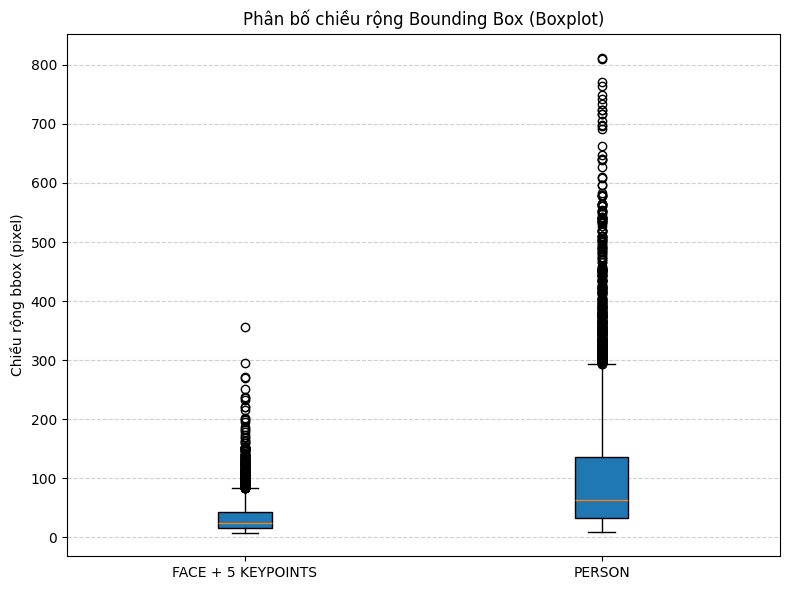

C:\Users\ACER\AppData\Local\Temp\ipykernel_20836\695410992.py:113: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


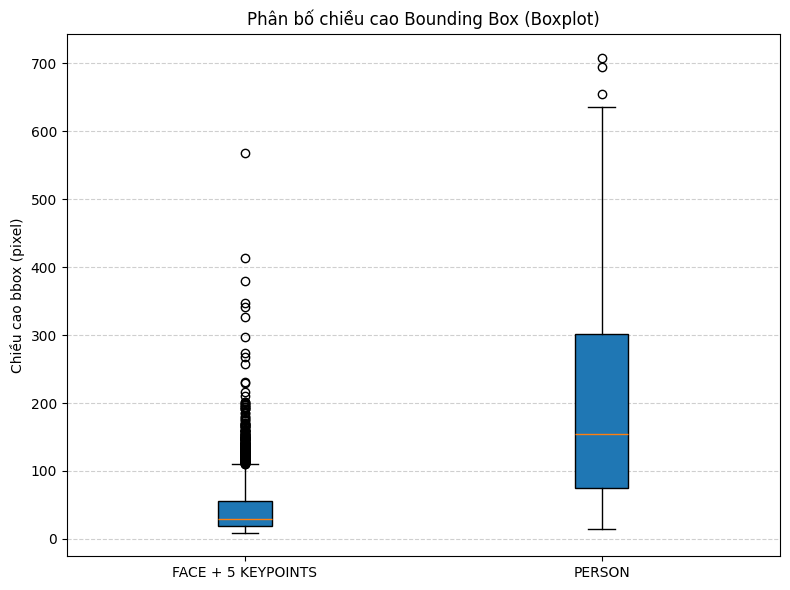

In [3]:
import pathlib
from collections import defaultdict
from PIL import Image
import numpy as np

label_dir = pathlib.Path("output_yolo/labels")
image_dir = pathlib.Path("output_yolo/images")

# lưu (w, h) theo class
bbox_sizes = defaultdict(list)

missing_images = 0
bad_labels = 0

for label_file in label_dir.rglob("*.txt"):
    img_file = image_dir / (label_file.stem + ".png")

    if not img_file.exists():
        missing_images += 1
        continue

    # kích thước ảnh thật
    with Image.open(img_file) as img:
        img_w, img_h = img.size

    with open(label_file, "r") as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]

    for line in lines:
        parts = line.split()

        # cần ít nhất: class + xywh
        if len(parts) < 5:
            bad_labels += 1
            continue

        cls_id = int(parts[0])

        # ✅ xywh đúng chuẩn YOLO
        x = float(parts[1])
        y = float(parts[2])
        w = float(parts[3])
        h = float(parts[4])

        # đổi sang pixel thật
        bw = w * img_w
        bh = h * img_h

        bbox_sizes[map_class[cls_id]].append((bw, bh))

        # (optional) check keypoint format cho class face
        if cls_id == 1:
            expected_len = 1 + 4 + 5 * 3
            if len(parts) != expected_len:
                print(f"⚠️ Bad keypoint format: {label_file.name}")

# ======= THỐNG KÊ =======
print("\n📊 BBOX SIZE STATISTICS (PIXEL)")

for cls_id in sorted(bbox_sizes.keys()):
    sizes = bbox_sizes[cls_id]
    ws = np.array([s[0] for s in sizes])
    hs = np.array([s[1] for s in sizes])

    print(f"\nClass {cls_id}:")
    print(f"  Count       : {len(sizes)}")
    print(f"  Avg width   : {ws.mean():.2f}px")
    print(f"  Avg height  : {hs.mean():.2f}px")
    print(f"  Min (w, h)  : ({ws.min():.1f}, {hs.min():.1f})")
    print(f"  Max (w, h)  : ({ws.max():.1f}, {hs.max():.1f})")

print("\n🧾 EXTRA INFO")
print(f"Missing images: {missing_images}")
print(f"Bad labels    : {bad_labels}")

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

data = []
labels = []

for cls_name in sorted(bbox_sizes.keys()):
    ws = [s[0] for s in bbox_sizes[cls_name]]
    data.append(ws)
    labels.append(str(cls_name))

plt.boxplot(
    data,
    labels=labels,
    showfliers=True,
    patch_artist=True
)

plt.ylabel("Chiều rộng bbox (pixel)")
plt.title("Phân bố chiều rộng Bounding Box (Boxplot)")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 6))

data = []
labels = []

for cls_name in sorted(bbox_sizes.keys()):
    hs = [s[1] for s in bbox_sizes[cls_name]]
    data.append(hs)
    labels.append(str(cls_name))

plt.boxplot(
    data,
    labels=labels,
    showfliers=True,
    patch_artist=True
)

plt.ylabel("Chiều cao bbox (pixel)")
plt.title("Phân bố chiều cao Bounding Box (Boxplot)")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


🖼 Image : 6_12_1231_frame_003577.png
📄 Label : 6_12_1231_frame_003577.txt


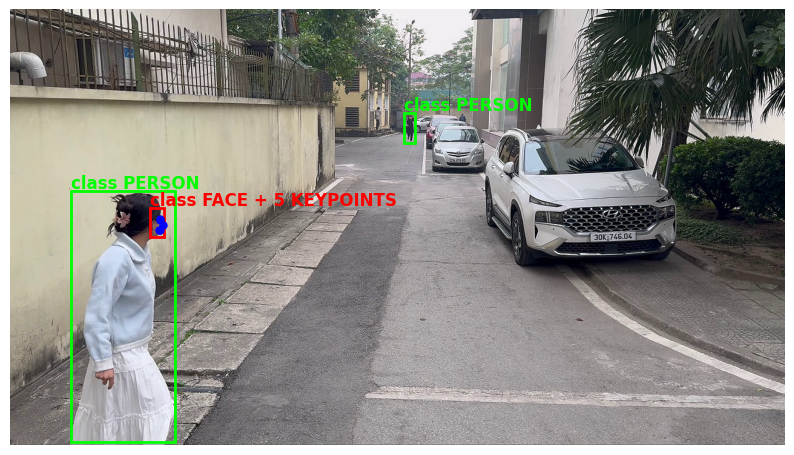

🖼 Image : 6_12_1231_frame_008363.png
📄 Label : 6_12_1231_frame_008363.txt


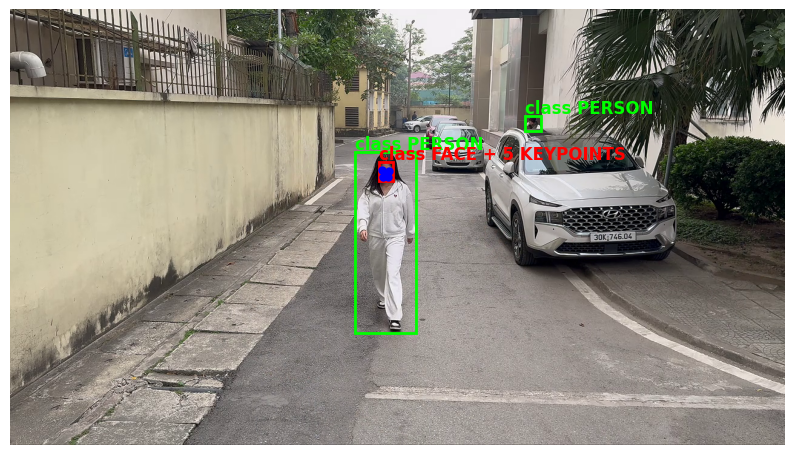

🖼 Image : 6_12_1231_frame_014307.png
📄 Label : 6_12_1231_frame_014307.txt


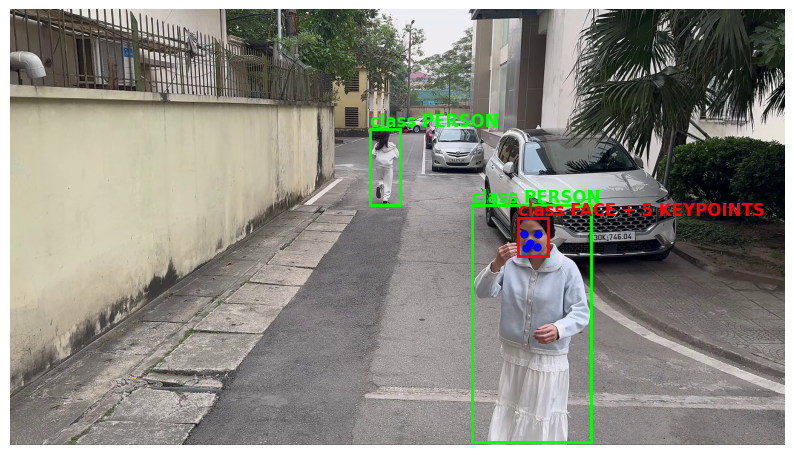

🖼 Image : 27_9_cam2_frame_021660.png
📄 Label : 27_9_cam2_frame_021660.txt


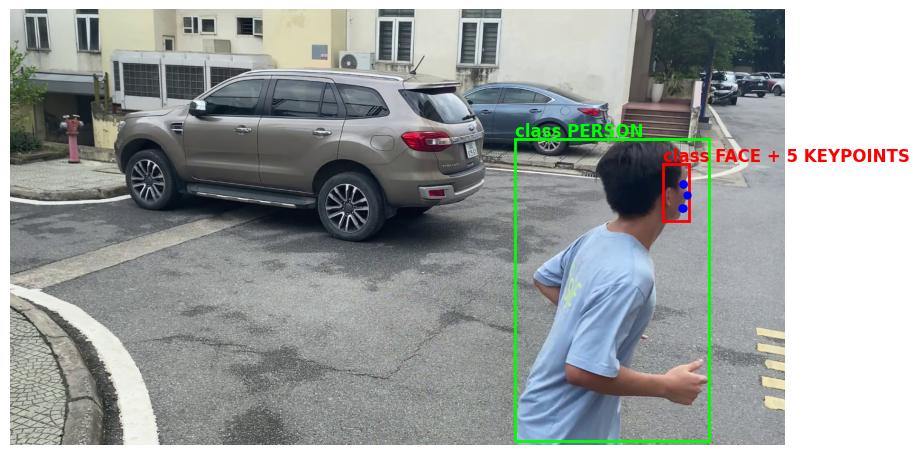

🖼 Image : 6_12_IMG_1550_frame_022452.png
📄 Label : 6_12_IMG_1550_frame_022452.txt


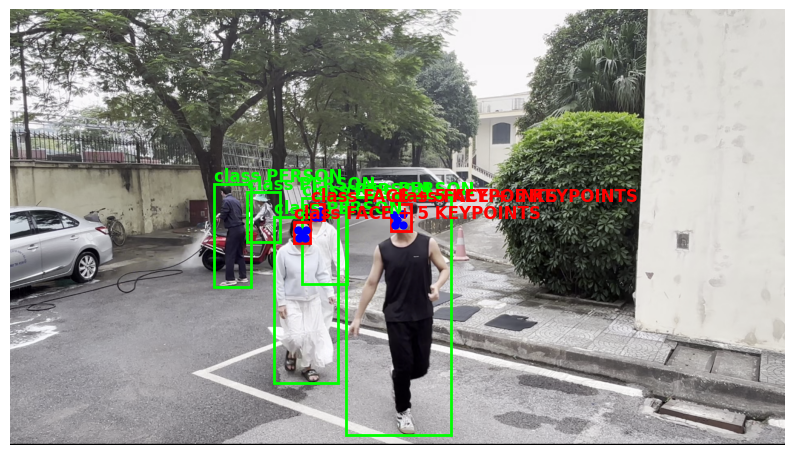

In [8]:
import random
import pathlib
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

label_dir = pathlib.Path("D:\haui_sict_fitness_score\output_yolo/labels")
image_dir = pathlib.Path("D:\haui_sict_fitness_score\output_yolo/images")

# lấy tất cả label files
label_files = list(label_dir.rglob("*.txt"))
assert len(label_files) > 0, "No label files found"

# màu theo class
COLORS = {
    0: (0, 1, 0),    # person - green
    1: (1, 0, 0),    # face - red
}
map_class = {
    0: "PERSON",
    1: "FACE + 5 KEYPOINTS"
}
# random 5 label files
random_files = random.sample(label_files, min(5, len(label_files)))

for label_file in random_files:
    img_file = image_dir / (label_file.stem + ".png")
    print(f"🖼 Image : {img_file.name}")
    print(f"📄 Label : {label_file.name}")

    # đọc ảnh
    img = cv2.imread(str(img_file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    fig, ax = plt.subplots(1, figsize=(10, 7))
    ax.imshow(img)

    with open(label_file, "r") as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]

    for line in lines:
        parts = line.split()
        cls_id = int(parts[0])

        # YOLO xywh
        x = float(parts[1]) * w
        y = float(parts[2]) * h
        bw = float(parts[3]) * w
        bh = float(parts[4]) * h

        x1 = x - bw / 2
        y1 = y - bh / 2

        color = COLORS.get(cls_id, (1, 1, 1))

        # vẽ bbox
        rect = patches.Rectangle(
            (x1, y1), bw, bh,
            linewidth=2,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            x1, max(y1 - 5, 0),
            f"class {map_class[cls_id]}",
            color=color,
            fontsize=12,
            weight='bold'
        )

        # vẽ keypoints nếu là face
        if cls_id == 1 and len(parts) >= 1 + 4 + 15:
            kps = parts[5:]
            for i in range(0, len(kps), 3):
                kp_x = float(kps[i]) * w
                kp_y = float(kps[i + 1]) * h
                v = int(float(kps[i + 2]))
                if v > 0:
                    ax.plot(kp_x, kp_y, 'bo', markersize=5)

    ax.axis('off')
    plt.show()


Total images: 3347
Images with mismatched person & face: 1739


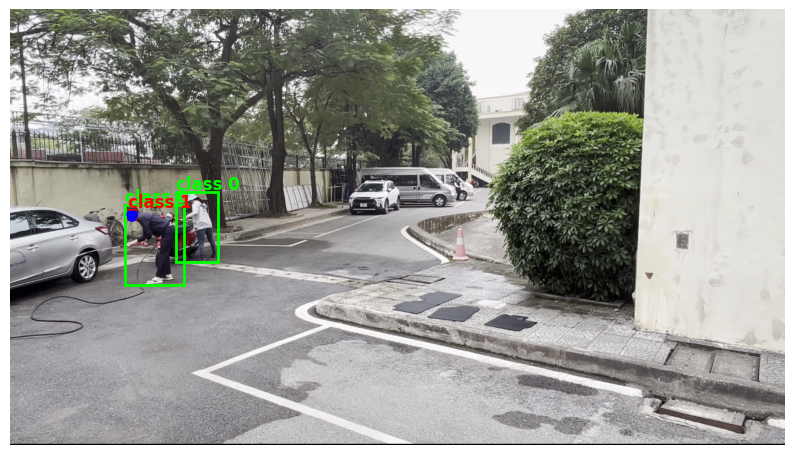

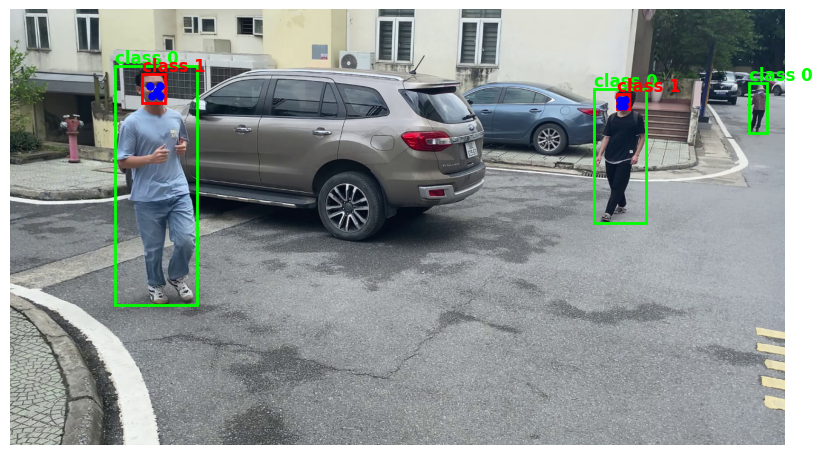

error: OpenCV(4.8.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:182: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [6]:
import pathlib
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random

label_dir = pathlib.Path("output_yolo/labels")
image_dir = pathlib.Path("output_yolo/images")

label_files = list(label_dir.rglob("*.txt"))
assert len(label_files) > 0, "No label files found"

# màu theo class
COLORS = {
    0: (0, 1, 0),    # person - green
    1: (1, 0, 0),    # face - red
}

# list lưu path ảnh có số lượng person và face không bằng nhau
mismatch_imgs = []

# duyệt từng label file
for label_file in label_files:
    person_count = 0
    face_count = 0

    with open(label_file, "r") as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]

    for line in lines:
        cls_id = int(line.split()[0])
        if cls_id == 0:
            person_count += 1
        elif cls_id == 1:
            face_count += 1

    if person_count != face_count:
        img_file = image_dir / (label_file.stem + ".png")
        mismatch_imgs.append(img_file)

# thống kê
print(f"Total images: {len(label_files)}")
print(f"Images with mismatched person & face: {len(mismatch_imgs)}")

# visualize 5 ảnh ngẫu nhiên
if mismatch_imgs:
    visualize_imgs = random.sample(mismatch_imgs, min(5, len(mismatch_imgs)))
    for img_file in visualize_imgs:
        img = cv2.imread(str(img_file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        # lấy label tương ứng
        label_file = label_dir / (img_file.stem + ".txt")
        with open(label_file, "r") as f:
            lines = [l.strip() for l in f.readlines() if l.strip()]

        fig, ax = plt.subplots(1, figsize=(10, 7))
        ax.imshow(img)

        for line in lines:
            parts = line.split()
            cls_id = int(parts[0])

            x = float(parts[1]) * w
            y = float(parts[2]) * h
            bw = float(parts[3]) * w
            bh = float(parts[4]) * h
            x1 = x - bw / 2
            y1 = y - bh / 2

            color = COLORS.get(cls_id, (1, 1, 1))

            # vẽ bbox
            rect = patches.Rectangle((x1, y1), bw, bh, linewidth=2, edgecolor=color, facecolor="none")
            ax.add_patch(rect)
            ax.text(x1, max(y1 - 5, 0), f"class {cls_id}", color=color, fontsize=12, weight='bold')

            # nếu face có keypoints thì vẽ
            if cls_id == 1 and len(parts) >= 1 + 4 + 15:
                kps = parts[5:]
                for i in range(0, len(kps), 3):
                    kp_x = float(kps[i]) * w
                    kp_y = float(kps[i + 1]) * h
                    v = int(float(kps[i + 2]))
                    if v > 0:
                        ax.plot(kp_x, kp_y, 'bo', markersize=5)

        ax.axis('off')
        plt.show()



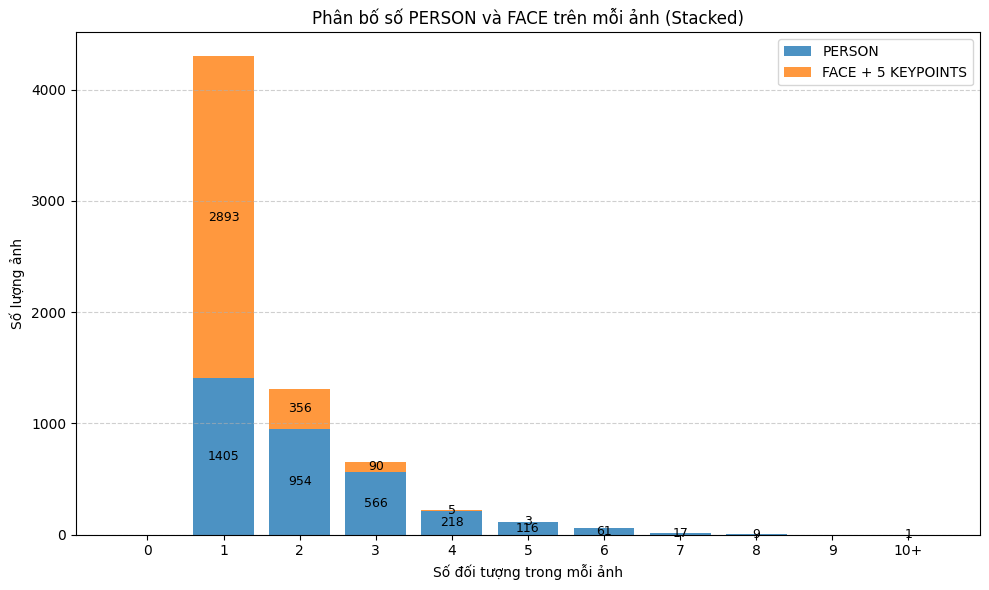

In [1]:
import pathlib
import matplotlib.pyplot as plt
import numpy as np

# ================== PATH ==================
label_dir = pathlib.Path("output_yolo/labels")
label_files = list(label_dir.rglob("*.txt"))
assert len(label_files) > 0, "No label files found"

# ================== THỐNG KÊ ==================
person_counts = []
face_counts = []

for label_file in label_files:
    person_count = 0
    face_count = 0

    with open(label_file, "r", encoding="utf-8") as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]

    for line in lines:
        cls_id = int(line.split()[0])
        if cls_id == 0:
            person_count += 1
        elif cls_id == 1:
            face_count += 1

    person_counts.append(min(person_count, 10))
    face_counts.append(min(face_count, 10))

# ================== HISTOGRAM DATA ==================
bins = np.arange(0, 11)  # 0 → 10 (10 = 10+)

person_hist = np.bincount(person_counts, minlength=11)
face_hist = np.bincount(face_counts, minlength=11)

# ================== VẼ BIỂU ĐỒ (STACKED) ==================
plt.figure(figsize=(10, 6))

plt.bar(
    bins,
    person_hist,
    label="PERSON",
    alpha=0.8
)

plt.bar(
    bins,
    face_hist,
    bottom=person_hist,
    label="FACE + 5 KEYPOINTS",
    alpha=0.8
)

plt.xticks(bins, [str(i) if i < 10 else "10+" for i in bins])
plt.xlabel("Số đối tượng trong mỗi ảnh")
plt.ylabel("Số lượng ảnh")
plt.title("Phân bố số PERSON và FACE trên mỗi ảnh (Stacked)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)

# ================== GHI SỐ LÊN CỘT ==================
for x in bins:
    if person_hist[x] > 0:
        plt.text(
            x,
            person_hist[x] / 2,
            person_hist[x],
            ha="center",
            va="center",
            fontsize=9
        )

    if face_hist[x] > 0:
        plt.text(
            x,
            person_hist[x] + face_hist[x] / 2,
            face_hist[x],
            ha="center",
            va="center",
            fontsize=9
        )

plt.tight_layout()
plt.show()



========== DATASET STATISTICS ==========
Total PERSON: 7030
Total FACE: 3910
PERSON area: min=182, max=530735, mean=31646
FACE area:   min=73, max=202285, mean=2476
Mean PERSON / Image ratio: 0.0343
Mean FACE / Image ratio:   0.0027
Mean FACE / PERSON ratio:  0.1854



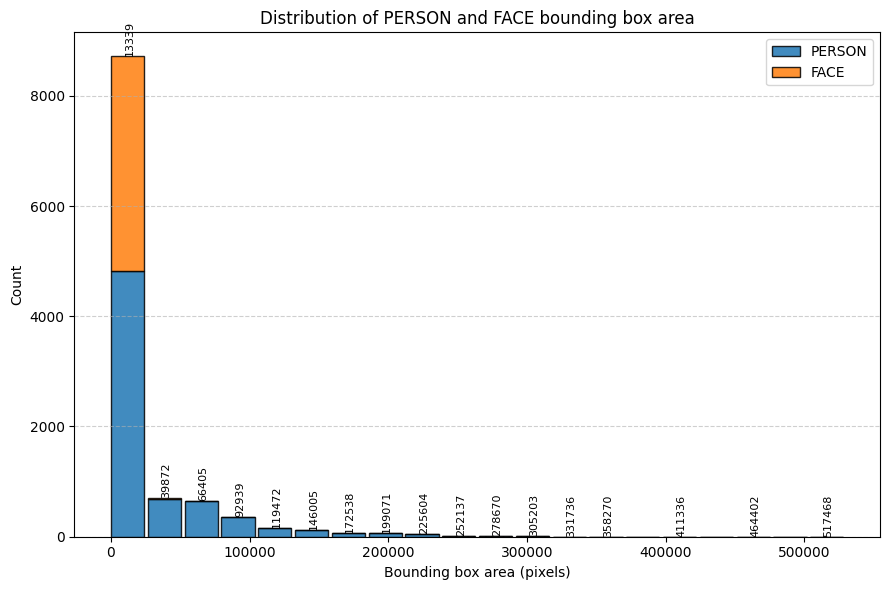

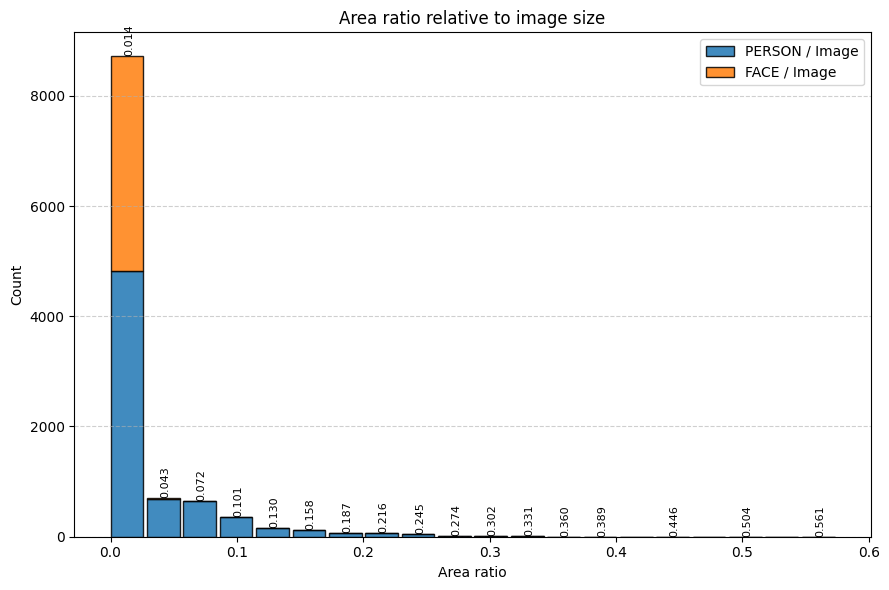

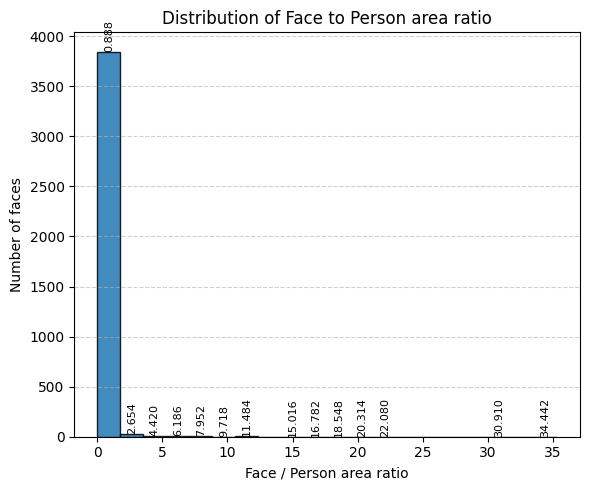

In [1]:
import pathlib
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ================== PATH ==================
label_dir = pathlib.Path("output_yolo/labels")
image_dir = pathlib.Path("output_yolo/images")

label_files = list(label_dir.rglob("*.txt"))
assert len(label_files) > 0, "No label files found"

# ================== READ IMAGE UNICODE ==================
def imread_unicode(path):
    arr = np.fromfile(str(path), dtype=np.uint8)
    return cv2.imdecode(arr, cv2.IMREAD_COLOR)

# ================== STORAGE ==================
person_area_list = []
face_area_list = []

person_ratio_list = []
face_image_ratio_list = []

face_person_ratio_list = []

img_exts = [".jpg", ".png", ".jpeg"]

# ================== PARSE DATA ==================
for label_file in label_files:
    img_file = None
    for ext in img_exts:
        p = image_dir / (label_file.stem + ext)
        if p.exists():
            img_file = p
            break
    if img_file is None:
        continue

    img = imread_unicode(img_file)
    if img is None:
        continue

    h, w = img.shape[:2]
    img_area = h * w

    with open(label_file, "r", encoding="utf-8") as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]

    person_bboxes = []

    for line in lines:
        parts = line.split()
        cls_id = int(parts[0])

        x = float(parts[1]) * w
        y = float(parts[2]) * h
        bw = float(parts[3]) * w
        bh = float(parts[4]) * h
        area = bw * bh

        x1 = x - bw / 2
        y1 = y - bh / 2

        if cls_id == 0:  # PERSON
            person_area_list.append(area)
            person_ratio_list.append(area / img_area)
            person_bboxes.append((x1, y1, bw, bh))

        elif cls_id == 1:  # FACE
            face_area_list.append(area)
            face_image_ratio_list.append(area / img_area)

            if person_bboxes:
                min_dist = float("inf")
                matched_area = None
                for px, py, pw, ph in person_bboxes:
                    cx, cy = px + pw / 2, py + ph / 2
                    dist = (x - cx) ** 2 + (y - cy) ** 2
                    if dist < min_dist:
                        min_dist = dist
                        matched_area = pw * ph
                if matched_area:
                    face_person_ratio_list.append(area / matched_area)

# ================== NUMERICAL STATISTICS ==================
print("\n========== DATASET STATISTICS ==========")
print(f"Total PERSON: {len(person_area_list)}")
print(f"Total FACE: {len(face_area_list)}")
print(f"PERSON area: min={np.min(person_area_list):.0f}, max={np.max(person_area_list):.0f}, mean={np.mean(person_area_list):.0f}")
print(f"FACE area:   min={np.min(face_area_list):.0f}, max={np.max(face_area_list):.0f}, mean={np.mean(face_area_list):.0f}")
print(f"Mean PERSON / Image ratio: {np.mean(person_ratio_list):.4f}")
print(f"Mean FACE / Image ratio:   {np.mean(face_image_ratio_list):.4f}")
print(f"Mean FACE / PERSON ratio:  {np.mean(face_person_ratio_list):.4f}")
print("========================================\n")

# =========================================================
# 1️⃣ STACKED HISTOGRAM: PERSON AREA + FACE AREA
# =========================================================
plt.figure(figsize=(9, 6))

bins = np.histogram_bin_edges(
    person_area_list + face_area_list,
    bins=20
)

bin_width = np.diff(bins)
bar_width = bin_width * 0.9

person_hist, _ = np.histogram(person_area_list, bins=bins)
face_hist, _ = np.histogram(face_area_list, bins=bins)

plt.bar(bins[:-1], person_hist, width=bar_width, align="edge",
        label="PERSON", edgecolor="black", alpha=0.85)

plt.bar(bins[:-1], face_hist, width=bar_width, align="edge",
        bottom=person_hist, label="FACE", edgecolor="black", alpha=0.85)

# ---- GHI GIÁ TRỊ TRỤC X (BIN CENTER) ----
for i, (p, f) in enumerate(zip(person_hist, face_hist)):
    if p + f == 0:
        continue
    x_center = (bins[i] + bins[i+1]) / 2
    plt.text(
        x_center,
        p + f,
        f"{x_center:.0f}",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90
    )

plt.xlabel("Bounding box area (pixels)")
plt.ylabel("Count")
plt.title("Distribution of PERSON and FACE bounding box area")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# =========================================================
# 2️⃣ STACKED HISTOGRAM: PERSON / IMAGE + FACE / IMAGE
# =========================================================
plt.figure(figsize=(9, 6))

bins = np.histogram_bin_edges(
    person_ratio_list + face_image_ratio_list,
    bins=20
)

bin_width = np.diff(bins)
bar_width = bin_width * 0.9

person_hist, _ = np.histogram(person_ratio_list, bins=bins)
face_hist, _ = np.histogram(face_image_ratio_list, bins=bins)

plt.bar(bins[:-1], person_hist, width=bar_width, align="edge",
        label="PERSON / Image", edgecolor="black", alpha=0.85)

plt.bar(bins[:-1], face_hist, width=bar_width, align="edge",
        bottom=person_hist, label="FACE / Image", edgecolor="black", alpha=0.85)

# ---- GHI GIÁ TRỊ TRỤC X ----
for i, (p, f) in enumerate(zip(person_hist, face_hist)):
    if p + f == 0:
        continue
    x_center = (bins[i] + bins[i+1]) / 2
    plt.text(
        x_center,
        p + f,
        f"{x_center:.3f}",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90
    )

plt.xlabel("Area ratio")
plt.ylabel("Count")
plt.title("Area ratio relative to image size")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# =========================================================
# 3️⃣ HISTOGRAM: FACE / PERSON RATIO
# =========================================================
plt.figure(figsize=(6, 5))

n, bins, patches = plt.hist(
    face_person_ratio_list,
    bins=20,
    edgecolor="black",
    alpha=0.85
)

for i, count in enumerate(n):
    if count == 0:
        continue
    x_center = (bins[i] + bins[i+1]) / 2
    plt.text(
        x_center,
        count,
        f"{x_center:.3f}",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90
    )

plt.xlabel("Face / Person area ratio")
plt.ylabel("Number of faces")
plt.title("Distribution of Face to Person area ratio")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


Eye-Eye: mean=11.79, min=0.09, max=135.65
Eye-Nose: mean=9.19, min=2.04, max=137.08
Nose-Mouth: mean=8.47, min=0.63, max=120.82


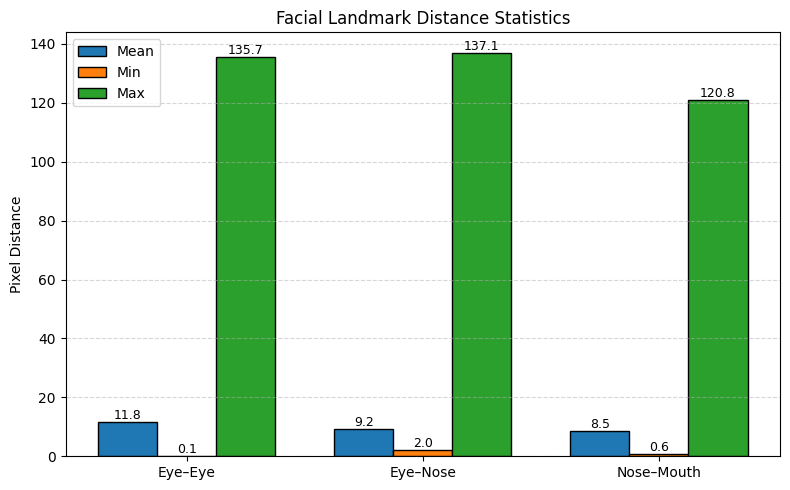

In [6]:
import pathlib
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ================== THƯ MỤC ==================
label_dir = pathlib.Path("output_yolo/labels")
image_dir = pathlib.Path("output_yolo/images")

label_files = list(label_dir.rglob("*.txt"))
assert len(label_files) > 0, "No label files found"

# ================== ĐỌC ẢNH UNICODE ==================
def imread_unicode(path):
    arr = np.fromfile(str(path), dtype=np.uint8)
    return cv2.imdecode(arr, cv2.IMREAD_COLOR)

# ================== DANH SÁCH ==================
eye_dist_list = []
eye_nose_list = []
nose_mouth_list = []

# ================== ĐỌC DỮ LIỆU ==================
for label_file in label_files:
    img_file = image_dir / (label_file.stem + ".png")
    if not img_file.exists():
        continue

    img = imread_unicode(img_file)
    if img is None:
        continue

    h, w = img.shape[:2]

    with open(label_file, "r", encoding="utf-8") as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]

    for line in lines:
        parts = line.split()
        cls_id = int(parts[0])
        if cls_id != 1:
            continue  # face only

        bw = float(parts[3]) * w  # face width

        if len(parts) >= 1 + 4 + 15:
            kps = [float(v) for v in parts[5:]]

            left_eye = (kps[0]*w, kps[1]*h)
            right_eye = (kps[3]*w, kps[4]*h)
            nose = (kps[6]*w, kps[7]*h)
            left_mouth = (kps[9]*w, kps[10]*h)
            right_mouth = (kps[12]*w, kps[13]*h)

            mouth = (
                (left_mouth[0]+right_mouth[0])/2,
                (left_mouth[1]+right_mouth[1])/2
            )

            eye_dist = np.linalg.norm(np.array(left_eye) - np.array(right_eye))
            eye_center = (
                (left_eye[0]+right_eye[0])/2,
                (left_eye[1]+right_eye[1])/2
            )
            eye_nose = np.linalg.norm(np.array(eye_center) - np.array(nose))
            nose_mouth = np.linalg.norm(np.array(nose) - np.array(mouth))

            eye_dist_list.append(eye_dist)
            eye_nose_list.append(eye_nose)
            nose_mouth_list.append(nose_mouth)

# ================== THỐNG KÊ ==================
stats = {
    "Eye–Eye": [
        np.mean(eye_dist_list),
        np.min(eye_dist_list),
        np.max(eye_dist_list)
    ],
    "Eye–Nose": [
        np.mean(eye_nose_list),
        np.min(eye_nose_list),
        np.max(eye_nose_list)
    ],
    "Nose–Mouth": [
        np.mean(nose_mouth_list),
        np.min(nose_mouth_list),
        np.max(nose_mouth_list)
    ]
}

# print như bạn yêu cầu
print(f"Eye-Eye: mean={stats['Eye–Eye'][0]:.2f}, min={stats['Eye–Eye'][1]:.2f}, max={stats['Eye–Eye'][2]:.2f}")
print(f"Eye-Nose: mean={stats['Eye–Nose'][0]:.2f}, min={stats['Eye–Nose'][1]:.2f}, max={stats['Eye–Nose'][2]:.2f}")
print(f"Nose-Mouth: mean={stats['Nose–Mouth'][0]:.2f}, min={stats['Nose–Mouth'][1]:.2f}, max={stats['Nose–Mouth'][2]:.2f}")

# ================== VẼ BIỂU ĐỒ CỘT ==================
labels = list(stats.keys())
mean_vals = [stats[k][0] for k in labels]
min_vals = [stats[k][1] for k in labels]
max_vals = [stats[k][2] for k in labels]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8, 5))

bars1 = plt.bar(x - width, mean_vals, width, label="Mean", edgecolor="black")
bars2 = plt.bar(x, min_vals, width, label="Min", edgecolor="black")
bars3 = plt.bar(x + width, max_vals, width, label="Max", edgecolor="black")

plt.xticks(x, labels)
plt.ylabel("Pixel Distance")
plt.title("Facial Landmark Distance Statistics")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

# ghi số lên cột
def add_labels(bars):
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h,
            f"{h:.1f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.tight_layout()
plt.show()


In [7]:
import pathlib
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

label_dir = pathlib.Path("output_yolo/labels")
image_dir = pathlib.Path("output_yolo/images")

label_files = list(label_dir.rglob("*.txt"))
assert len(label_files) > 0, "No label files found"

def imread_unicode(path):
    arr = np.fromfile(str(path), dtype=np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    return img

# --- Danh sách face bất thường ---
abnormal_faces = []

# Ngưỡng pixel theo trục x hoặc y
threshold_px = 30  # bạn có thể chỉnh 30 hoặc 50

img_exts = [".png", ".jpg", ".jpeg"]

# --- Tìm các face abnormal ---
for label_file in label_files:
    img_file = None
    for ext in img_exts:
        candidate = image_dir / (label_file.stem + ext)
        if candidate.exists():
            img_file = candidate
            break
    if img_file is None:
        continue

    img = imread_unicode(img_file)
    if img is None:
        continue

    h, w = img.shape[:2]

    with open(label_file, "r", encoding="utf-8") as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]

    for line in lines:
        parts = line.split()
        cls_id = int(parts[0])
        if cls_id != 1:
            continue  # chỉ xét face

        # YOLO bbox -> pixels
        x = float(parts[1]) * w
        y = float(parts[2]) * h
        bw = float(parts[3]) * w
        bh = float(parts[4]) * h
        x1 = x - bw/2
        y1 = y - bh/2
        x2 = x + bw/2
        y2 = y + bh/2

        if len(parts) < 1 + 4 + 15:
            continue  # không đủ landmark

        kps = [float(v) for v in parts[5:]]
        left_eye = (kps[0]*w, kps[1]*h)
        right_eye = (kps[3]*w, kps[4]*h)
        nose = (kps[6]*w, kps[7]*h)
        left_mouth = (kps[9]*w, kps[10]*h)
        right_mouth = (kps[12]*w, kps[13]*h)

        # Khoảng cách theo x hoặc y
        left_dx = abs(left_eye[0] - left_mouth[0])
        left_dy = abs(left_eye[1] - left_mouth[1])
        right_dx = abs(right_eye[0] - right_mouth[0])
        right_dy = abs(right_eye[1] - right_mouth[1])

        if left_dx < threshold_px or left_dy < threshold_px or \
           right_dx < threshold_px or right_dy < threshold_px:
            abnormal_faces.append({
                "img_file": img_file,
                "bbox": (x1, y1, x2, y2),
                "landmarks": [left_eye, right_eye, nose, left_mouth, right_mouth],
                "left_dx": left_dx,
                "left_dy": left_dy,
                "right_dx": right_dx,
                "right_dy": right_dy
            })

print(f"Total abnormal faces (trục x hoặc y < {threshold_px}px): {len(abnormal_faces)}")

# --- Visualize 5 ảnh ngẫu nhiên ---


Total abnormal faces (trục x hoặc y < 30px): 3910


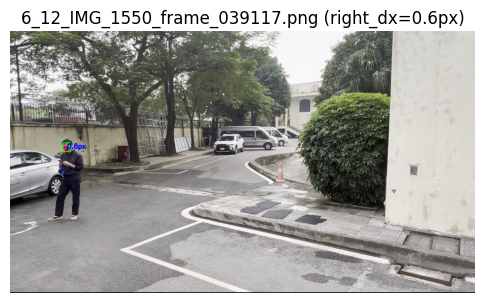

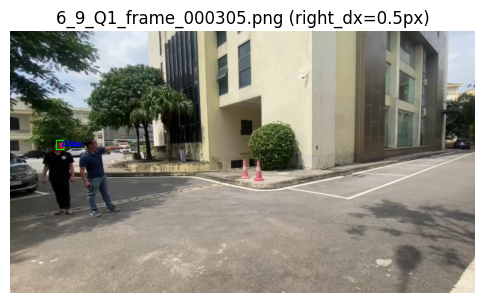

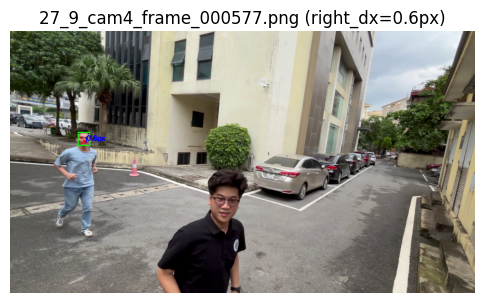

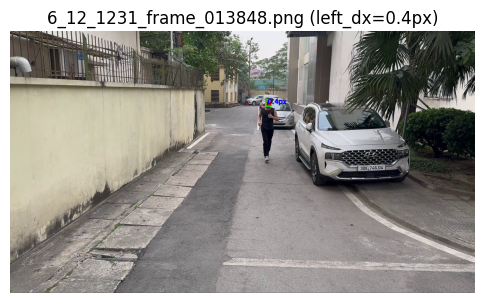

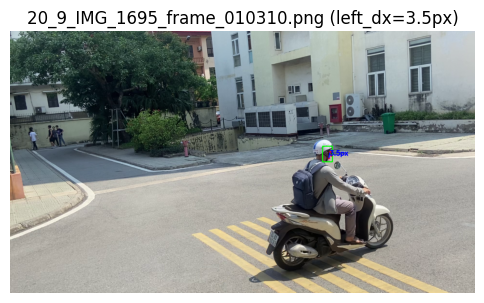

In [8]:
num_show = min(5, len(abnormal_faces))
samples = random.sample(abnormal_faces, num_show)

for face in samples:
    img_file = face["img_file"]
    img = cv2.imread(str(img_file))
    if img is None:
        continue

    x1, y1, x2, y2 = [int(v) for v in face["bbox"]]
    left_eye, right_eye, nose, left_mouth, right_mouth = face["landmarks"]

    # vẽ bbox face
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # vẽ landmarks
    for (x, y) in [left_eye, right_eye, nose, left_mouth, right_mouth]:
        cv2.circle(img, (int(x), int(y)), 3, (0,0,255), -1)

    # highlight khoảng cách trục x hoặc y nhỏ nhất
    dists = [
        ("left_dx", left_eye, left_mouth, face["left_dx"]),
        ("left_dy", left_eye, left_mouth, face["left_dy"]),
        ("right_dx", right_eye, right_mouth, face["right_dx"]),
        ("right_dy", right_eye, right_mouth, face["right_dy"]),
    ]
    # tìm khoảng cách nhỏ nhất
    min_label, pt1, pt2, min_val = min(dists, key=lambda x:x[3])
    cv2.line(img, (int(pt1[0]), int(pt1[1])), (int(pt2[0]), int(pt2[1])), (255,0,0), 2)
    mid = ((int(pt1[0]+pt2[0])//2), (int(pt1[1]+pt2[1])//2))
    cv2.putText(img, f"{min_val:.1f}px", mid, cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)

    # convert BGR -> RGB để matplotlib hiển thị
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(img_rgb)
    plt.title(f"{img_file.name} ({min_label}={min_val:.1f}px)")
    plt.axis("off")
    plt.show()


In [1]:
import cv2
from ultralytics import YOLO

# Load model
model = YOLO("weights/yolo11m.pt")

img_path = r"D:\NCKH_Cham_diem_the_duc\9bb3db88-b8a7-4c50-8537-2321c66d28e9.jpg"

# Predict
results = model.predict(
    source=img_path,
    conf=0.7,
    save=False,
    verbose=False
)

# Read image
img = cv2.imread(img_path)

# Get boxes
boxes = results[0].boxes

idx = 0
for box in boxes:
    cls_id = int(box.cls.item())
    if cls_id == 0:  # class 0
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        crop = img[y1:y2, x1:x2]
        cv2.imwrite(f"crop_class0_{idx}.jpg", crop)
        idx += 1

print(f"Saved {idx} images of class 0")


Saved 1 images of class 0


In [6]:
from pathlib import Path
from collections import defaultdict
import random
import shutil

# ================== CONFIG ==================
img_dir = Path("output_yolo/images")
out_dir = Path("one_frame_per_video")
RANDOM_SEED = 42

out_dir.mkdir(exist_ok=True)
random.seed(RANDOM_SEED)

# ================== STEP 1: RENAME (ALL SPACE -> _) ==================
for p in img_dir.iterdir():
    if not p.is_file():
        continue

    new_name = p.name.replace(" ", "_")
    if new_name != p.name:
        p.rename(p.with_name(new_name))

print("✔ Finished renaming spaces -> underscores")

# ================== STEP 2: GROUP BY 3 PREFIX ==================
video_groups = defaultdict(list)

for img in img_dir.iterdir():
    if img.is_file() and img.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        parts = img.stem.split("_")

        # nếu tên không đủ 3 phần thì lấy toàn bộ
        video_id = "_".join(parts[:3]) if len(parts) >= 3 else img.stem
        video_groups[video_id].append(img)

print(f"✔ Detected {len(video_groups)} videos")

# ================== STEP 3: RANDOM 1 FRAME / VIDEO ==================
for video_id, frames in video_groups.items():
    selected = random.choice(frames)
    shutil.copy(selected, out_dir / selected.name)

print(f"✔ Selected {len(list(out_dir.iterdir()))} frames")


✔ Finished renaming spaces -> underscores
✔ Detected 32 videos
✔ Selected 32 frames


In [ ]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import matplotlib.patches as patches

# ================== PATH ==================
label_dir = pathlib.Path("output_yolo/labels")
label_files = list(label_dir.rglob("*.txt"))
assert len(label_files) > 0, "No label files found"

# ================== CLASS MAP ==================
class_names = {
    0: "person",
    1: "face"
}

class_colors = {
    0: "tab:blue",
    1: "tab:red"
}

# ================== STORAGE ==================
class_counts = defaultdict(int)
bbox_data = defaultdict(list)
# bbox_data[class] = [(x_center, y_center, w, h), ...] normalized YOLO format

# ================== READ LABELS ==================
for label_file in label_files:
    with open(label_file, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    for line in lines:
        parts = line.split()
        if len(parts) < 5:
            continue

        cls_id = int(parts[0])
        x = float(parts[1])
        y = float(parts[2])
        w = float(parts[3])
        h = float(parts[4])

        class_counts[cls_id] += 1
        bbox_data[cls_id].append((x, y, w, h))

# ================== FIGURE ==================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# =========================================================
# 1. Instances per Class
# =========================================================
ax = axes[0, 0]
classes = sorted(class_counts.keys())
counts = [class_counts[c] for c in classes]
labels = [class_names.get(c, str(c)) for c in classes]
colors = [class_colors.get(c, "gray") for c in classes]

bars = ax.bar(labels, counts, color=colors)
ax.set_title("Instances per Class")
ax.set_ylabel("Count")
ax.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# =========================================================
# 2. Centered Bounding Box Overlay
# =========================================================
ax = axes[0, 1]
ax.set_title("Centered Bounding Box Overlay")

# Center all boxes at (0,0), using normalized size scaled for visibility
scale = 700

for cls_id in classes:
    for x, y, w, h in bbox_data[cls_id]:
        rect = patches.Rectangle(
            (-w * scale / 2, -h * scale / 2),
            w * scale,
            h * scale,
            fill=False,
            edgecolor=class_colors.get(cls_id, "gray"),
            alpha=0.08,
            linewidth=0.8
        )
        ax.add_patch(rect)

ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlim(-450, 450)
ax.set_ylim(-400, 400)
ax.set_aspect("equal", adjustable="box")

legend_handles = [
    patches.Patch(edgecolor=class_colors[c], facecolor="none", label=class_names[c])
    for c in classes
]
ax.legend(handles=legend_handles, loc="upper right", title="Class Legend")
ax.grid(True, linestyle="--", alpha=0.3)

# =========================================================
# 3. BBox Center Distribution
# =========================================================
ax = axes[1, 0]
ax.set_title("BBox Center Distribution (X vs Y)")

for cls_id in classes:
    arr = np.array(bbox_data[cls_id])
    ax.scatter(
        arr[:, 0],
        arr[:, 1],
        s=8,
        alpha=0.35,
        color=class_colors.get(cls_id, "gray"),
        label=class_names.get(cls_id, str(cls_id))
    )

ax.set_xlabel("Center X (normalized)")
ax.set_ylabel("Center Y (normalized)")
ax.set_xlim(0, 1)
ax.set_ylim(1, 0)  # ảnh thường có gốc tọa độ ở góc trên trái
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

# =========================================================
# 4. BBox Size Distribution
# =========================================================
ax = axes[1, 1]
ax.set_title("BBox Size Distribution (W vs H)")

for cls_id in classes:
    arr = np.array(bbox_data[cls_id])
    ax.scatter(
        arr[:, 2],
        arr[:, 3],
        s=8,
        alpha=0.35,
        color=class_colors.get(cls_id, "gray"),
        label=class_names.get(cls_id, str(cls_id))
    )

ax.set_xlabel("Width (normalized)")
ax.set_ylabel("Height (normalized)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

plt.tight_layout()
plt.savefig("distribution_xywh_and_bbox.png", dpi=200, bbox_inches="tight")
plt.show()

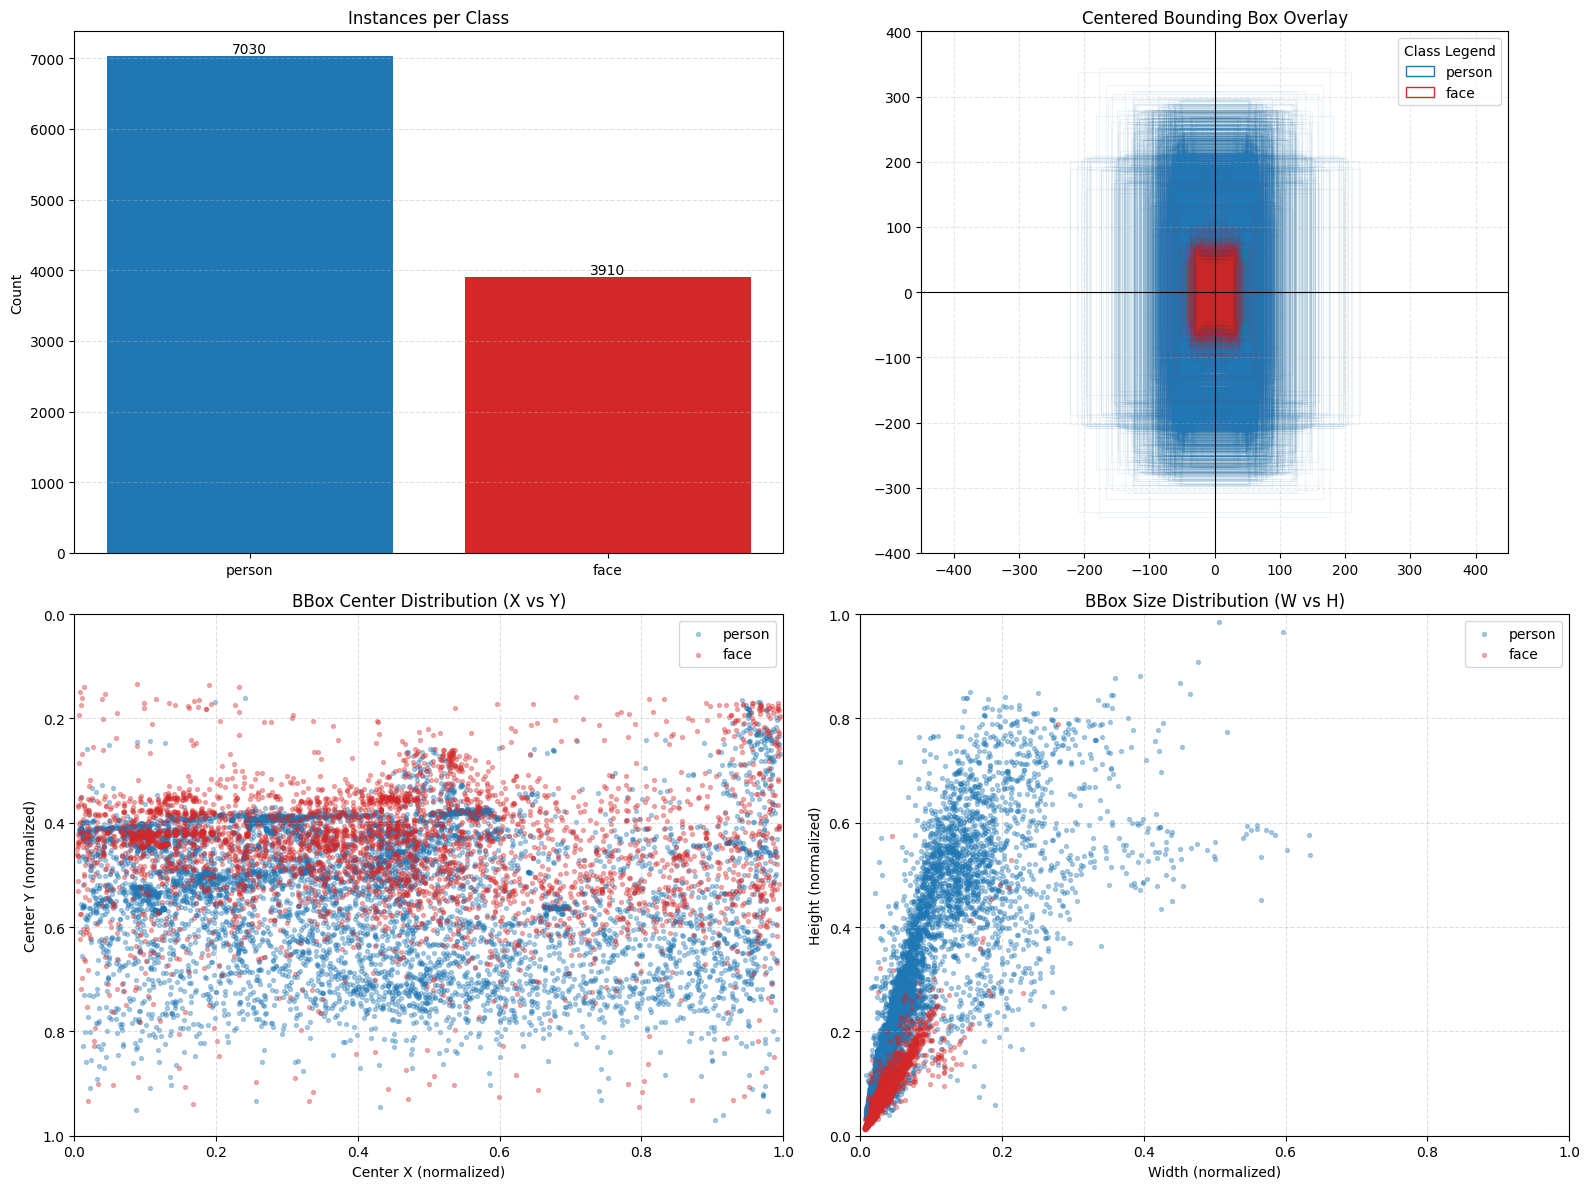

In [16]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import matplotlib.patches as patches

# ================== PATH ==================
label_dir = pathlib.Path("D:\haui_sict_fitness_score\output_yolo/labels")
label_files = list(label_dir.rglob("*.txt"))
assert len(label_files) > 0, "No label files found"

# ================== CLASS MAP ==================
class_names = {
    0: "person",
    1: "face"
}

class_colors = {
    0: "tab:blue",
    1: "tab:red"
}

# ================== STORAGE ==================
class_counts = defaultdict(int)
bbox_data = defaultdict(list)
# bbox_data[class] = [(x_center, y_center, w, h), ...] normalized YOLO format

# ================== READ LABELS ==================
for label_file in label_files:
    with open(label_file, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    for line in lines:
        parts = line.split()
        if len(parts) < 5:
            continue

        cls_id = int(parts[0])
        x = float(parts[1])
        y = float(parts[2])
        w = float(parts[3])
        h = float(parts[4])

        class_counts[cls_id] += 1
        bbox_data[cls_id].append((x, y, w, h))

# ================== FIGURE ==================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# =========================================================
# 1. Instances per Class
# =========================================================
ax = axes[0, 0]
classes = sorted(class_counts.keys())
counts = [class_counts[c] for c in classes]
labels = [class_names.get(c, str(c)) for c in classes]
colors = [class_colors.get(c, "gray") for c in classes]

bars = ax.bar(labels, counts, color=colors)
ax.set_title("Instances per Class")
ax.set_ylabel("Count")
ax.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# =========================================================
# 2. Centered Bounding Box Overlay
# =========================================================
ax = axes[0, 1]
ax.set_title("Centered Bounding Box Overlay")

# Center all boxes at (0,0), using normalized size scaled for visibility
scale = 700

for cls_id in classes:
    for x, y, w, h in bbox_data[cls_id]:
        rect = patches.Rectangle(
            (-w * scale / 2, -h * scale / 2),
            w * scale,
            h * scale,
            fill=False,
            edgecolor=class_colors.get(cls_id, "gray"),
            alpha=0.08,
            linewidth=0.8
        )
        ax.add_patch(rect)

ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlim(-450, 450)
ax.set_ylim(-400, 400)
ax.set_aspect("equal", adjustable="box")

legend_handles = [
    patches.Patch(edgecolor=class_colors[c], facecolor="none", label=class_names[c])
    for c in classes
]
ax.legend(handles=legend_handles, loc="upper right", title="Class Legend")
ax.grid(True, linestyle="--", alpha=0.3)

# =========================================================
# 3. BBox Center Distribution
# =========================================================
ax = axes[1, 0]
ax.set_title("BBox Center Distribution (X vs Y)")

for cls_id in classes:
    arr = np.array(bbox_data[cls_id])
    ax.scatter(
        arr[:, 0],
        arr[:, 1],
        s=8,
        alpha=0.35,
        color=class_colors.get(cls_id, "gray"),
        label=class_names.get(cls_id, str(cls_id))
    )

ax.set_xlabel("Center X (normalized)")
ax.set_ylabel("Center Y (normalized)")
ax.set_xlim(0, 1)
ax.set_ylim(1, 0)  # ảnh thường có gốc tọa độ ở góc trên trái
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

# =========================================================
# 4. BBox Size Distribution
# =========================================================
ax = axes[1, 1]
ax.set_title("BBox Size Distribution (W vs H)")

for cls_id in classes:
    arr = np.array(bbox_data[cls_id])
    ax.scatter(
        arr[:, 2],
        arr[:, 3],
        s=8,
        alpha=0.35,
        color=class_colors.get(cls_id, "gray"),
        label=class_names.get(cls_id, str(cls_id))
    )

ax.set_xlabel("Width (normalized)")
ax.set_ylabel("Height (normalized)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

plt.tight_layout()
plt.savefig("distribution_xywh_and_bbox.png", dpi=200, bbox_inches="tight")
plt.show()

In [28]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from itertools import combinations

# ====== CONFIG ======
IMAGE_DIR = Path("D:\haui_sict_fitness_score\output_yolo/images")   # sửa theo thư mục ảnh của bạn
LABEL_DIR = Path("D:\haui_sict_fitness_score\output_yolo/labels")   # sửa theo thư mục label YOLO của bạn

CLASS_NAMES = {
    0: "person",
    1: "face"
}

# Nếu label face có 5 keypoints theo YOLO pose:
# class x y w h kpt1_x kpt1_y kpt1_v ... kpt5_x kpt5_y kpt5_v
KEYPOINT_NAMES = [
    "Left Eye",
    "Right Eye",
    "Nose",
    "Left Mouth",
    "Right Mouth"
]

In [30]:
def find_image_for_label(label_path: Path, label_dir: Path, image_dir: Path):
    exts = [".jpg", ".jpeg", ".png", ".bmp", ".JPG", ".JPEG", ".PNG", ".BMP"]

    # Cách 1: tìm theo cấu trúc thư mục tương ứng
    # labels/train/a.txt -> images/train/a.jpg
    try:
        rel = label_path.relative_to(label_dir)
        for ext in exts:
            candidate = image_dir / rel.with_suffix(ext)
            if candidate.exists():
                return candidate
    except ValueError:
        pass

    # Cách 2: fallback tìm đệ quy theo stem
    for ext in exts:
        matches = list(image_dir.rglob(f"{label_path.stem}{ext}"))
        if len(matches) > 0:
            return matches[0]

    return None

In [36]:
from pathlib import Path
import pandas as pd
import shutil

# ================== PATH ==================
IMAGE_DIR = Path(r"D:\haui_sict_fitness_score\output_yolo\images")
LABEL_DIR = Path(r"D:\haui_sict_fitness_score\output_yolo\labels")

VALID_IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

# ================== LOAD FILES ==================
image_files = sorted([
    p for p in IMAGE_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in VALID_IMAGE_EXTS
])

label_files = sorted([
    p for p in LABEL_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() == ".txt"
])

# map stem -> file
image_map = {}
for p in image_files:
    image_map.setdefault(p.stem, []).append(p)

label_map = {}
for p in label_files:
    label_map.setdefault(p.stem, []).append(p)

image_stems = set(image_map.keys())
label_stems = set(label_map.keys())

labels_without_image = sorted(label_stems - image_stems)
images_without_label = sorted(image_stems - label_stems)

print("Total image files:", len(image_files))
print("Total label files:", len(label_files))
print("Labels không có ảnh:", len(labels_without_image))
print("Ảnh không có label:", len(images_without_label))

# ================== CREATE RENAME PLAN ==================
rename_rows = []
skip_rows = []

for label_path in label_files:
    old_stem = label_path.stem

    # Nếu label đã khớp ảnh thì không đụng vào
    if old_stem in image_stems:
        continue

    # Chỉ xử lý case dấu cách -> gạch dưới
    new_stem = old_stem.replace(" ", "_")

    # Nếu sau khi thay space -> underscore mà vẫn không có ảnh thì bỏ qua
    if new_stem not in image_stems:
        skip_rows.append({
            "old_label": str(label_path),
            "old_stem": old_stem,
            "new_stem_candidate": new_stem,
            "reason": "No matching image after space -> underscore"
        })
        continue

    # Nếu có nhiều ảnh cùng stem thì bỏ qua để tránh nhầm
    if len(image_map[new_stem]) != 1:
        skip_rows.append({
            "old_label": str(label_path),
            "old_stem": old_stem,
            "new_stem_candidate": new_stem,
            "reason": "Multiple images with same target stem"
        })
        continue

    new_label_path = label_path.with_name(new_stem + ".txt")

    # Nếu file label đích đã tồn tại thì bỏ qua để tránh overwrite
    if new_label_path.exists():
        skip_rows.append({
            "old_label": str(label_path),
            "old_stem": old_stem,
            "new_stem_candidate": new_stem,
            "reason": "Target label already exists"
        })
        continue

    rename_rows.append({
        "old_label": str(label_path),
        "new_label": str(new_label_path),
        "matched_image": str(image_map[new_stem][0]),
        "old_stem": old_stem,
        "new_stem": new_stem
    })

df_rename = pd.DataFrame(rename_rows)
df_skip = pd.DataFrame(skip_rows)

df_rename.to_csv("rename_label_plan.csv", index=False, encoding="utf-8-sig")
df_skip.to_csv("rename_label_skipped.csv", index=False, encoding="utf-8-sig")

print("\nCó thể rename:", len(df_rename))
print("Bị bỏ qua:", len(df_skip))
print("Đã xuất: rename_label_plan.csv")
print("Đã xuất: rename_label_skipped.csv")

display(df_rename.head(20))
display(df_skip.head(20))

Total image files: 3347
Total label files: 3347
Labels không có ảnh: 0
Ảnh không có label: 0

Có thể rename: 0
Bị bỏ qua: 0
Đã xuất: rename_label_plan.csv
Đã xuất: rename_label_skipped.csv


""


""


In [25]:
from pathlib import Path
import pandas as pd
import shutil

PLAN_FILE = Path("rename_label_plan.csv")
BACKUP_DIR = Path(r"D:\haui_sict_fitness_score\output_yolo\labels_backup_before_rename")

df_plan = pd.read_csv(PLAN_FILE)

print("Số file sẽ rename:", len(df_plan))

# Tạo backup
BACKUP_DIR.mkdir(parents=True, exist_ok=True)

renamed = []
skipped = []

for _, row in df_plan.iterrows():
    old_path = Path(row["old_label"])
    new_path = Path(row["new_label"])

    if not old_path.exists():
        skipped.append({
            "old_label": str(old_path),
            "new_label": str(new_path),
            "reason": "Old label not found"
        })
        continue

    if new_path.exists():
        skipped.append({
            "old_label": str(old_path),
            "new_label": str(new_path),
            "reason": "Target label already exists"
        })
        continue

    # Backup trước khi rename
    backup_path = BACKUP_DIR / old_path.name
    shutil.copy2(old_path, backup_path)

    # Rename thật
    old_path.rename(new_path)

    renamed.append({
        "old_label": str(old_path),
        "new_label": str(new_path),
        "backup": str(backup_path)
    })

df_renamed = pd.DataFrame(renamed)
df_skipped_apply = pd.DataFrame(skipped)

df_renamed.to_csv("renamed_labels_done.csv", index=False, encoding="utf-8-sig")
df_skipped_apply.to_csv("renamed_labels_skipped_apply.csv", index=False, encoding="utf-8-sig")

print("Rename thành công:", len(df_renamed))
print("Bỏ qua khi apply:", len(df_skipped_apply))
print("Backup tại:", BACKUP_DIR)

display(df_renamed.head(20))
display(df_skipped_apply.head(20))

Số file sẽ rename: 432
Rename thành công: 432
Bỏ qua khi apply: 0
Backup tại: D:\haui_sict_fitness_score\output_yolo\labels_backup_before_rename


,old_label,new_label,backup
0,D:\haui_sict_fitness_score\output_yolo\labels\...,D:\haui_sict_fitness_score\output_yolo\labels\...,D:\haui_sict_fitness_score\output_yolo\labels_...
1,D:\haui_sict_fitness_score\output_yolo\labels\...,D:\haui_sict_fitness_score\output_yolo\labels\...,D:\haui_sict_fitness_score\output_yolo\labels_...
2,D:\haui_sict_fitness_score\output_yolo\labels\...,D:\haui_sict_fitness_score\output_yolo\labels\...,D:\haui_sict_fitness_score\output_yolo\labels_...
3,D:\haui_sict_fitness_score\output_yolo\labels\...,D:\haui_sict_fitness_score\output_yolo\labels\...,D:\haui_sict_fitness_score\output_yolo\labels_...
4,D:\haui_sict_fitness_score\output_yolo\labels\...,D:\haui_sict_fitness_score\output_yolo\labels\...,D:\haui_sict_fitness_score\output_yolo\labels_...
5,D:\haui_sict_fitness_score\output_yolo\labels\...,D:\haui_sict_fitness_score\output_yolo\labels\...,D:\haui_sict_fitness_score\output_yolo\labels_...
6,D:\haui_sict_fitness_score\output_yolo\labels\...,D:\haui_sict_fitness_score\output_yolo\labels\...,D:\haui_sict_fitness_score\output_yolo\labels_...
7,D:\haui_sict_fitness_score\output_yolo\labels\...,D:\haui_sict_fitness_score\output_yolo\labels\...,D:\haui_sict_fitness_score\output_yolo\labels_...
8,D:\haui_sict_fitness_score\output_yolo\labels\...,D:\haui_sict_fitness_score\output_yolo\labels\...,D:\haui_sict_fitness_score\output_yolo\labels_...
9,D:\haui_sict_fitness_score\output_yolo\labels\...,D:\haui_sict_fitness_score\output_yolo\labels\...,D:\haui_sict_fitness_score\output_yolo\labels_...


""


In [27]:
from pathlib import Path

IMAGE_DIR = Path(r"D:\haui_sict_fitness_score\output_yolo\images")
LABEL_DIR = Path(r"D:\haui_sict_fitness_score\output_yolo\labels")

VALID_IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

image_files = sorted([
    p for p in IMAGE_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in VALID_IMAGE_EXTS
])

label_files = sorted([
    p for p in LABEL_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() == ".txt"
])

image_stems = set(p.stem for p in image_files)
label_stems = set(p.stem for p in label_files)

labels_without_image = sorted(label_stems - image_stems)
images_without_label = sorted(image_stems - label_stems)

print("Image files:", len(image_files))
print("Label files:", len(label_files))
print("Labels không có ảnh:", len(labels_without_image))
print("Ảnh không có label:", len(images_without_label))

if labels_without_image:
    print("\nVí dụ label không có ảnh:")
    for x in labels_without_image[:10]:
        print(x)

if images_without_label:
    print("\nVí dụ ảnh không có label:")
    for x in images_without_label[:10]:
        print(x)

Image files: 3347
Label files: 3347
Labels không có ảnh: 0
Ảnh không có label: 0


Image files: 3347
Label files: 3347
Duplicate image stems: 0
Labels không có ảnh: 0
Ảnh không có label: 0

========== DATASET READ RESULT ==========
Read fail image files: 0
Invalid label lines: 0
Total labels: 10940
class_name
person    7030
face      3910
Name: count, dtype: int64


,image,image_path,label_file,label_path,class_id,class_name,xc_norm,yc_norm,w_norm,h_norm,x_px,y_px,w_px,h_px,area_px,img_w,img_h
0,20_9_IMG_0030_frame_000230.png,D:\haui_sict_fitness_score\output_yolo\images\...,20_9_IMG_0030_frame_000230.txt,D:\haui_sict_fitness_score\output_yolo\labels\...,0,person,0.240217,0.461982,0.047593,0.203451,307.47776,332.62704,60.91904,146.48472,8923.708517,1280,720
1,20_9_IMG_0030_frame_000230.png,D:\haui_sict_fitness_score\output_yolo\images\...,20_9_IMG_0030_frame_000230.txt,D:\haui_sict_fitness_score\output_yolo\labels\...,1,face,0.243283,0.377811,0.012066,0.025718,311.40224,272.02392,15.44448,18.51696,285.984818,1280,720
2,20_9_IMG_0030_frame_000247.png,D:\haui_sict_fitness_score\output_yolo\images\...,20_9_IMG_0030_frame_000247.txt,D:\haui_sict_fitness_score\output_yolo\labels\...,0,person,0.250153,0.481954,0.063654,0.251677,320.19584,347.00688,81.47712,181.20744,14764.260334,1280,720
3,20_9_IMG_0030_frame_000247.png,D:\haui_sict_fitness_score\output_yolo\images\...,20_9_IMG_0030_frame_000247.txt,D:\haui_sict_fitness_score\output_yolo\labels\...,0,person,0.058746,0.469656,0.061383,0.156636,75.19488,338.15232,78.57024,112.77792,8860.988241,1280,720
4,20_9_IMG_0030_frame_000247.png,D:\haui_sict_fitness_score\output_yolo\images\...,20_9_IMG_0030_frame_000247.txt,D:\haui_sict_fitness_score\output_yolo\labels\...,1,face,0.252431,0.378447,0.013588,0.030400,323.11168,272.48184,17.39264,21.88800,380.690104,1280,720


,number_of_object,avg_labels_per_image,avg_width_px,avg_height_px,min_width_px,max_width_px,min_height_px,max_height_px
class_name,,,,,,,,
face,3910,1.17,34.08,43.48,7.71,356.29,9.42,567.76
person,7030,2.10,101.91,197.69,8.23,812.51,14.01,708.37


C:\Users\luumi\AppData\Local\Temp\ipykernel_55332\450203958.py:282: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(
C:\Users\luumi\AppData\Local\Temp\ipykernel_55332\450203958.py:298: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(


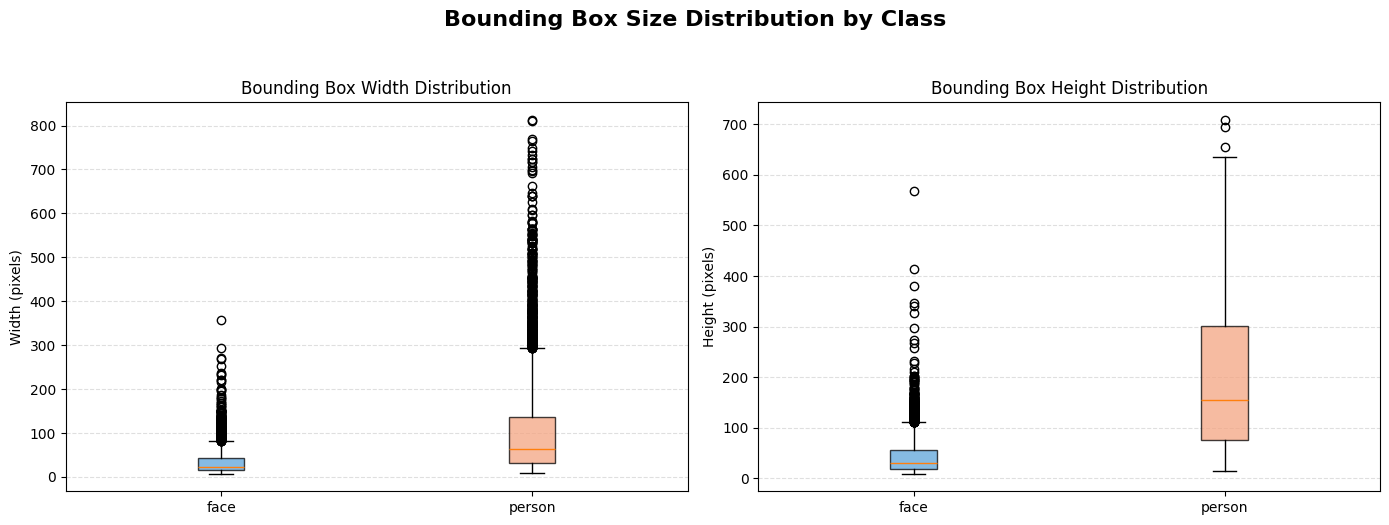

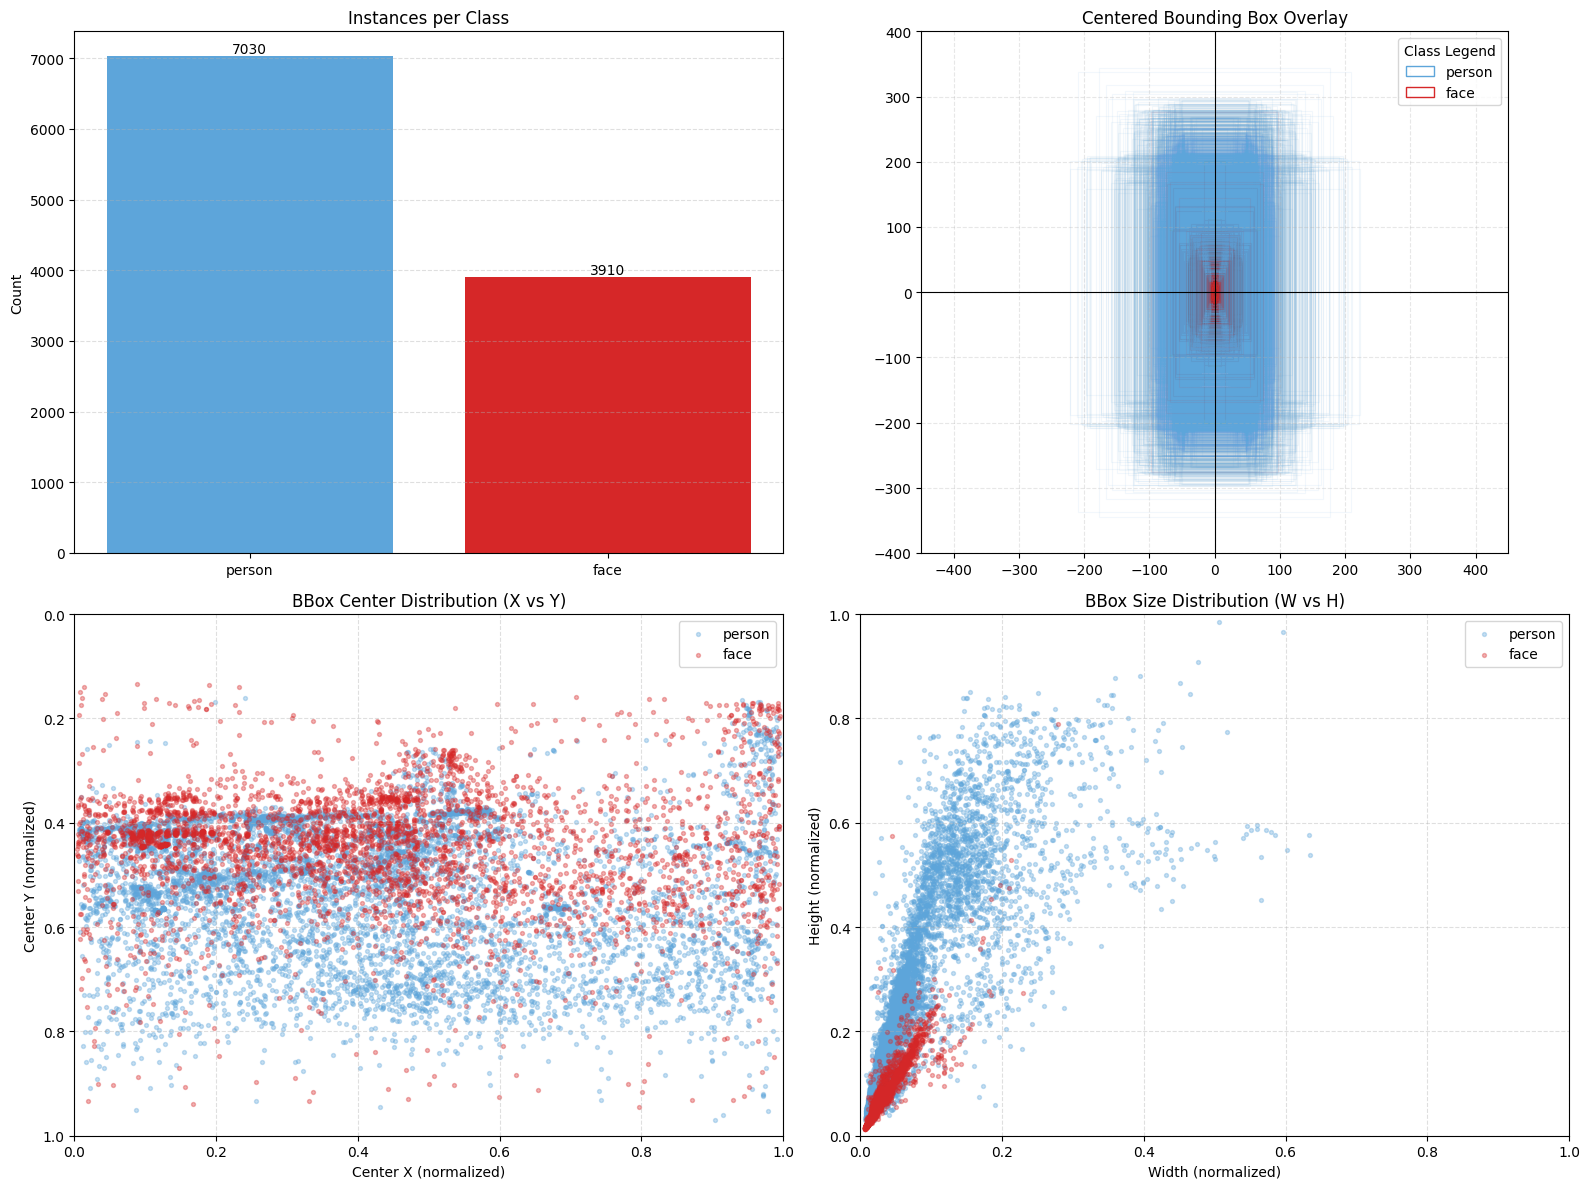

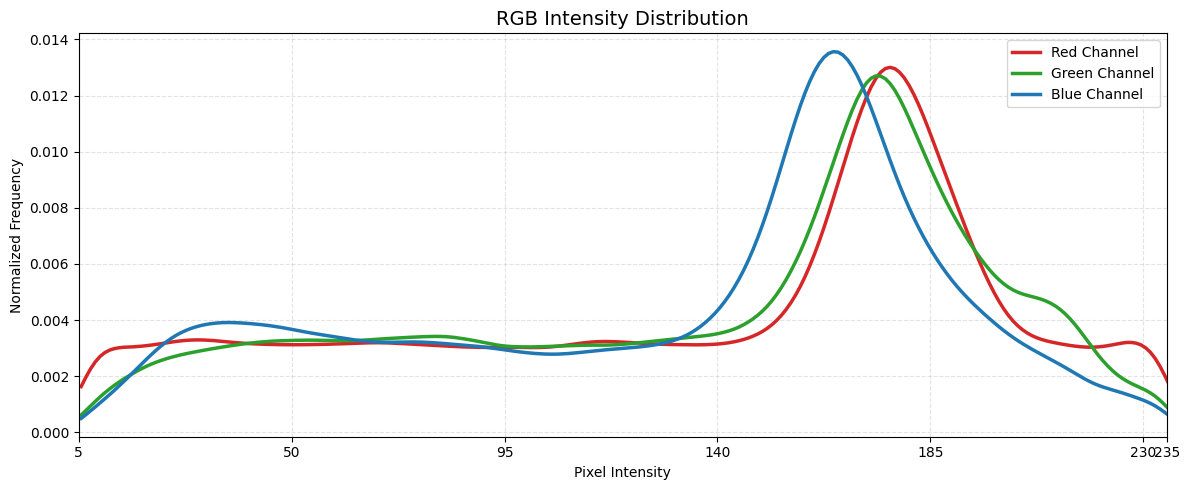


Total keypoint records: 3910
Total selected landmark distance rows: 31280


C:\Users\luumi\AppData\Local\Temp\ipykernel_55332\450203958.py:651: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


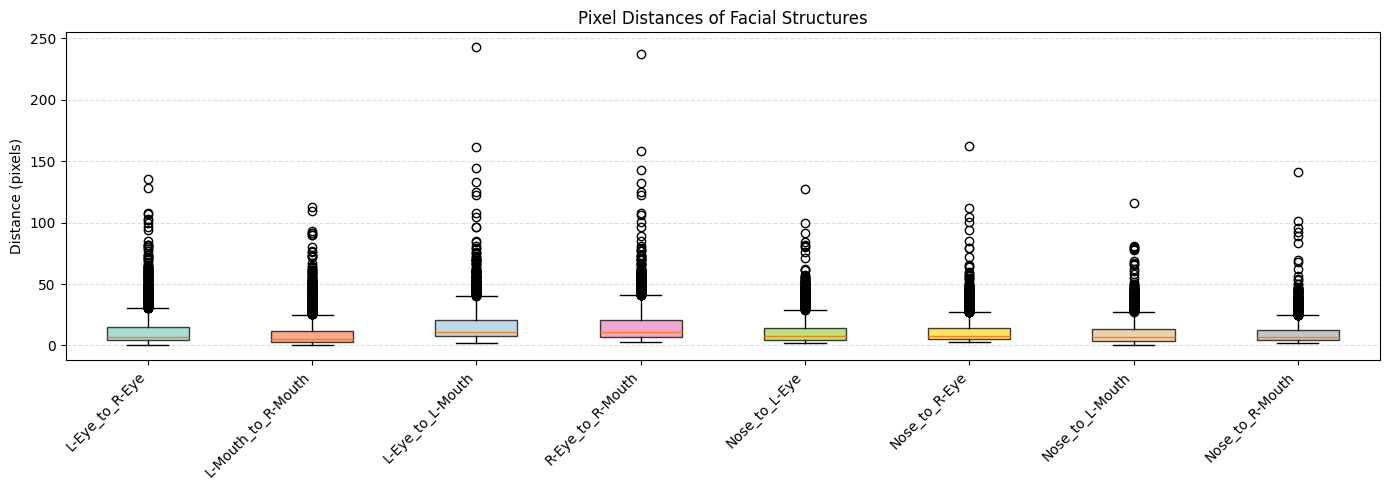


========== OUTPUT FILES ==========
D:\haui_sict_fitness_score\eda_outputs\bbox_summary_table.csv
D:\haui_sict_fitness_score\eda_outputs\fig4_bbox_width_height_boxplot_px.png
D:\haui_sict_fitness_score\eda_outputs\fig5_bbox_multi_panel_eda.png
D:\haui_sict_fitness_score\eda_outputs\fig6_rgb_intensity_distribution_smooth_5_235.png
D:\haui_sict_fitness_score\eda_outputs\fig7_landmark_distances.png
D:\haui_sict_fitness_score\eda_outputs\landmark_distance_statistics.csv


In [ ]:
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image


# =========================================================
# 1. CONFIG
# =========================================================

IMAGE_DIR = Path(r"D:\haui_sict_fitness_score\output_yolo\images")
LABEL_DIR = Path(r"D:\haui_sict_fitness_score\output_yolo\labels")
OUTPUT_DIR = Path(r"D:\haui_sict_fitness_score\eda_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VALID_IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

CLASS_NAMES = {
    0: "person",
    1: "face"
}

# Màu gần giống paper
CLASS_COLORS = {
    "face": "#5DA5DA",      # blue
    "person": "#F4A582"     # orange
}

CLASS_COLORS_BY_ID = {
    0: "#5DA5DA",   # person in scatter/overlay can use blue
    1: "#D62728"    # face red in scatter/overlay
}

KEYPOINT_NAMES = [
    "L_Eye",
    "R_Eye",
    "Nose",
    "L_Mouth",
    "R_Mouth"
]


# =========================================================
# 2. IMAGE READER USING PIL
# =========================================================

def get_image_size_pil(image_path: Path):
    with Image.open(image_path) as img:
        return img.size  # width, height


def read_image_rgb_pil(image_path: Path):
    with Image.open(image_path) as img:
        return np.array(img.convert("RGB"))


# =========================================================
# 3. LOAD IMAGE + LABEL FILES
# =========================================================

image_files = sorted([
    p for p in IMAGE_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in VALID_IMAGE_EXTS
])

label_files = sorted([
    p for p in LABEL_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() == ".txt"
])

image_map = {}
duplicate_image_stems = []

for p in image_files:
    if p.stem in image_map:
        duplicate_image_stems.append((p.stem, image_map[p.stem], p))
    else:
        image_map[p.stem] = p

image_stems = set(image_map.keys())
label_stems = set(p.stem for p in label_files)

labels_without_image = sorted(label_stems - image_stems)
images_without_label = sorted(image_stems - label_stems)

print("Image files:", len(image_files))
print("Label files:", len(label_files))
print("Duplicate image stems:", len(duplicate_image_stems))
print("Labels không có ảnh:", len(labels_without_image))
print("Ảnh không có label:", len(images_without_label))


# =========================================================
# 4. READ LABELS + BUILD DATAFRAME
# =========================================================

records = []
keypoint_records = []

read_fail_images = []
invalid_label_lines = []

for label_path in label_files:
    img_path = image_map.get(label_path.stem)

    if img_path is None:
        continue

    try:
        img_w, img_h = get_image_size_pil(img_path)
    except Exception as e:
        read_fail_images.append({
            "image_path": str(img_path),
            "label_path": str(label_path),
            "error": str(e)
        })
        continue

    with open(label_path, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f if line.strip()]

    for line_idx, line in enumerate(lines):
        parts = line.split()

        if len(parts) < 5:
            invalid_label_lines.append({
                "label_file": str(label_path),
                "line_idx": line_idx,
                "line": line,
                "reason": "Less than 5 columns"
            })
            continue

        try:
            cls_id = int(float(parts[0]))
            xc, yc, bw, bh = map(float, parts[1:5])
        except Exception as e:
            invalid_label_lines.append({
                "label_file": str(label_path),
                "line_idx": line_idx,
                "line": line,
                "reason": str(e)
            })
            continue

        x_px = xc * img_w
        y_px = yc * img_h
        w_px = bw * img_w
        h_px = bh * img_h

        records.append({
            "image": img_path.name,
            "image_path": str(img_path),
            "label_file": label_path.name,
            "label_path": str(label_path),
            "class_id": cls_id,
            "class_name": CLASS_NAMES.get(cls_id, str(cls_id)),
            "xc_norm": xc,
            "yc_norm": yc,
            "w_norm": bw,
            "h_norm": bh,
            "x_px": x_px,
            "y_px": y_px,
            "w_px": w_px,
            "h_px": h_px,
            "area_px": w_px * h_px,
            "img_w": img_w,
            "img_h": img_h
        })

        # Parse YOLO pose keypoints nếu có:
        # cls x y w h kp1_x kp1_y kp1_v ... kp5_x kp5_y kp5_v
        kp_values = parts[5:]

        if len(kp_values) >= 15:
            try:
                kp_values = list(map(float, kp_values[:15]))

                kps = {}
                for i, kp_name in enumerate(KEYPOINT_NAMES):
                    kx = kp_values[i * 3]
                    ky = kp_values[i * 3 + 1]
                    kv = kp_values[i * 3 + 2]

                    kps[kp_name] = {
                        "x_px": kx * img_w,
                        "y_px": ky * img_h,
                        "v": kv
                    }

                keypoint_records.append({
                    "image": img_path.name,
                    "label_file": label_path.name,
                    "line_idx": line_idx,
                    "class_id": cls_id,
                    "class_name": CLASS_NAMES.get(cls_id, str(cls_id)),
                    "keypoints": kps
                })

            except Exception as e:
                invalid_label_lines.append({
                    "label_file": str(label_path),
                    "line_idx": line_idx,
                    "line": line,
                    "reason": f"Keypoint parse error: {e}"
                })

df = pd.DataFrame(records)

print("\n========== DATASET READ RESULT ==========")
print("Read fail image files:", len(read_fail_images))
print("Invalid label lines:", len(invalid_label_lines))
print("Total labels:", len(df))
print(df["class_name"].value_counts())

display(df.head())


# =========================================================
# 5. SUMMARY TABLE
# =========================================================

summary = (
    df.groupby("class_name")
    .agg(
        number_of_object=("class_name", "count"),
        avg_width_px=("w_px", "mean"),
        avg_height_px=("h_px", "mean"),
        min_width_px=("w_px", "min"),
        max_width_px=("w_px", "max"),
        min_height_px=("h_px", "min"),
        max_height_px=("h_px", "max"),
    )
    .round(2)
)

num_images = df["image"].nunique()
summary["avg_labels_per_image"] = (
    df.groupby("class_name")["image"].count().div(num_images).round(2)
)

summary = summary[
    [
        "number_of_object",
        "avg_labels_per_image",
        "avg_width_px",
        "avg_height_px",
        "min_width_px",
        "max_width_px",
        "min_height_px",
        "max_height_px",
    ]
]

display(summary)
summary.to_csv(OUTPUT_DIR / "bbox_summary_table.csv", encoding="utf-8-sig")


# =========================================================
# 6. FIGURE 4: BBOX WIDTH/HEIGHT BOXPLOT
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_order = ["face", "person"]

width_data = [
    df[df["class_name"] == c]["w_px"].dropna()
    for c in class_order
]

height_data = [
    df[df["class_name"] == c]["h_px"].dropna()
    for c in class_order
]

# Width
bp1 = axes[0].boxplot(
    width_data,
    labels=class_order,
    patch_artist=True,
    showfliers=True
)

for patch, c in zip(bp1["boxes"], class_order):
    patch.set_facecolor(CLASS_COLORS[c])
    patch.set_alpha(0.75)

axes[0].set_title("Bounding Box Width Distribution")
axes[0].set_ylabel("Width (pixels)")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# Height
bp2 = axes[1].boxplot(
    height_data,
    labels=class_order,
    patch_artist=True,
    showfliers=True
)

for patch, c in zip(bp2["boxes"], class_order):
    patch.set_facecolor(CLASS_COLORS[c])
    patch.set_alpha(0.75)

axes[1].set_title("Bounding Box Height Distribution")
axes[1].set_ylabel("Height (pixels)")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

fig.suptitle(
    "Bounding Box Size Distribution by Class",
    fontsize=16,
    fontweight="bold",
    y=1.04
)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "fig4_bbox_width_height_boxplot_px.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# =========================================================
# 7. FIGURE 5: MULTI-PANEL BBOX EDA
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

classes = sorted(df["class_id"].unique())

# 7.1 Instances per Class
ax = axes[0, 0]
counts = df["class_id"].value_counts().sort_index()
labels = [CLASS_NAMES.get(c, str(c)) for c in counts.index]
colors = [CLASS_COLORS_BY_ID.get(c, "gray") for c in counts.index]

bars = ax.bar(labels, counts.values, color=colors)
ax.set_title("Instances per Class")
ax.set_ylabel("Count")
ax.grid(axis="y", linestyle="--", alpha=0.4)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# 7.2 Centered Bounding Box Overlay
ax = axes[0, 1]
ax.set_title("Centered Bounding Box Overlay")

scale = 700

for _, row in df.iterrows():
    color = CLASS_COLORS_BY_ID.get(row["class_id"], "gray")
    w = row["w_norm"] * scale
    h = row["h_norm"] * scale

    rect = patches.Rectangle(
        (-w / 2, -h / 2),
        w,
        h,
        fill=False,
        edgecolor=color,
        alpha=0.08,
        linewidth=0.8
    )
    ax.add_patch(rect)

ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlim(-450, 450)
ax.set_ylim(-400, 400)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", alpha=0.3)

legend_handles = [
    patches.Patch(
        edgecolor=CLASS_COLORS_BY_ID.get(c, "gray"),
        facecolor="none",
        label=CLASS_NAMES.get(c, str(c))
    )
    for c in classes
]
ax.legend(handles=legend_handles, loc="upper right", title="Class Legend")

# 7.3 BBox Center Distribution
ax = axes[1, 0]
ax.set_title("BBox Center Distribution (X vs Y)")

for cls_id in classes:
    subset = df[df["class_id"] == cls_id]
    ax.scatter(
        subset["xc_norm"],
        subset["yc_norm"],
        s=8,
        alpha=0.35,
        color=CLASS_COLORS_BY_ID.get(cls_id, "gray"),
        label=CLASS_NAMES.get(cls_id, str(cls_id))
    )

ax.set_xlabel("Center X (normalized)")
ax.set_ylabel("Center Y (normalized)")
ax.set_xlim(0, 1)
ax.set_ylim(1, 0)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

# 7.4 BBox Size Distribution
ax = axes[1, 1]
ax.set_title("BBox Size Distribution (W vs H)")

for cls_id in classes:
    subset = df[df["class_id"] == cls_id]
    ax.scatter(
        subset["w_norm"],
        subset["h_norm"],
        s=8,
        alpha=0.35,
        color=CLASS_COLORS_BY_ID.get(cls_id, "gray"),
        label=CLASS_NAMES.get(cls_id, str(cls_id))
    )

ax.set_xlabel("Width (normalized)")
ax.set_ylabel("Height (normalized)")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "fig5_bbox_multi_panel_eda.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# =========================================================
# 8. FIGURE 6: RGB INTENSITY DISTRIBUTION
# =========================================================

# =========================================================
# FIGURE 6-LIKE: RGB INTENSITY DISTRIBUTION, SMOOTHED
# Chỉ vẽ khoảng pixel intensity từ 5 đến 235
# =========================================================

MAX_IMAGES = 800
PIXEL_SAMPLE_PER_IMAGE = 8000

INTENSITY_MIN = 5
INTENSITY_MAX = 235

rng = np.random.default_rng(42)

r_values, g_values, b_values = [], [], []

for img_path in image_files[:MAX_IMAGES]:
    try:
        img_rgb = read_image_rgb_pil(img_path)
    except Exception:
        continue

    pixels = img_rgb.reshape(-1, 3)

    if len(pixels) > PIXEL_SAMPLE_PER_IMAGE:
        idx = rng.choice(
            len(pixels),
            size=PIXEL_SAMPLE_PER_IMAGE,
            replace=False
        )
        pixels = pixels[idx]

    r_values.extend(pixels[:, 0])
    g_values.extend(pixels[:, 1])
    b_values.extend(pixels[:, 2])


def smooth_curve(y, window_size=17, sigma=3.0):
    """
    Làm mượt histogram bằng Gaussian-like kernel.
    Không cần scipy.
    """
    half = window_size // 2
    x = np.arange(-half, half + 1)
    kernel = np.exp(-(x ** 2) / (2 * sigma ** 2))
    kernel = kernel / kernel.sum()
    return np.convolve(y, kernel, mode="same")


def get_smoothed_hist(values, min_val=5, max_val=235):
    values = np.asarray(values)

    # Chỉ giữ vùng 5 -> 235
    values = values[(values >= min_val) & (values <= max_val)]

    # bins: 5,6,7,...,235
    bins = np.arange(min_val, max_val + 2)
    hist, bin_edges = np.histogram(values, bins=bins, density=True)

    centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    hist_smooth = smooth_curve(hist, window_size=19, sigma=3.5)

    return centers, hist_smooth


x_r, y_r = get_smoothed_hist(r_values, INTENSITY_MIN, INTENSITY_MAX)
x_g, y_g = get_smoothed_hist(g_values, INTENSITY_MIN, INTENSITY_MAX)
x_b, y_b = get_smoothed_hist(b_values, INTENSITY_MIN, INTENSITY_MAX)

plt.figure(figsize=(12, 5))

plt.plot(
    x_r,
    y_r,
    linewidth=2.5,
    color="#D62728",
    label="Red Channel"
)

plt.plot(
    x_g,
    y_g,
    linewidth=2.5,
    color="#2CA02C",
    label="Green Channel"
)

plt.plot(
    x_b,
    y_b,
    linewidth=2.5,
    color="#1F77B4",
    label="Blue Channel"
)

plt.title("RGB Intensity Distribution", fontsize=14)
plt.xlabel("Pixel Intensity")
plt.ylabel("Normalized Frequency")

plt.xlim(5, 235)
plt.xticks([5, 50, 95, 140, 185, 230])
plt.grid(True, linestyle="--", alpha=0.35)
plt.legend()

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "fig6_rgb_intensity_distribution_smooth_5_235.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# =========================================================
# 9. FIGURE 7: LANDMARK DISTANCE, ONLY 8 MEANINGFUL PAIRS
# =========================================================

# Không dùng combinations tất cả cặp, vì sẽ sinh 10 cặp và bị thừa.
# Chỉ chọn 8 cặp chính giống tinh thần trong paper.
SELECTED_LANDMARK_PAIRS = [
    ("L_Eye", "R_Eye"),
    ("L_Mouth", "R_Mouth"),
    ("L_Eye", "L_Mouth"),
    ("R_Eye", "R_Mouth"),
    ("Nose", "L_Eye"),
    ("Nose", "R_Eye"),
    ("Nose", "L_Mouth"),
    ("Nose", "R_Mouth"),
]

pair_display_names = {
    ("L_Eye", "R_Eye"): "L-Eye_to_R-Eye",
    ("L_Mouth", "R_Mouth"): "L-Mouth_to_R-Mouth",
    ("L_Eye", "L_Mouth"): "L-Eye_to_L-Mouth",
    ("R_Eye", "R_Mouth"): "R-Eye_to_R-Mouth",
    ("Nose", "L_Eye"): "Nose_to_L-Eye",
    ("Nose", "R_Eye"): "Nose_to_R-Eye",
    ("Nose", "L_Mouth"): "Nose_to_L-Mouth",
    ("Nose", "R_Mouth"): "Nose_to_R-Mouth",
}

distance_rows = []

for item in keypoint_records:
    if item["class_name"] != "face":
        continue

    kps = item["keypoints"]

    for a_name, b_name in SELECTED_LANDMARK_PAIRS:
        if a_name not in kps or b_name not in kps:
            continue

        a = kps[a_name]
        b = kps[b_name]

        # Nếu keypoint có visibility = 0 thì bỏ qua
        if a["v"] <= 0 or b["v"] <= 0:
            continue

        dist = np.sqrt(
            (a["x_px"] - b["x_px"]) ** 2 +
            (a["y_px"] - b["y_px"]) ** 2
        )

        distance_rows.append({
            "image": item["image"],
            "label_file": item["label_file"],
            "pair": pair_display_names[(a_name, b_name)],
            "distance_px": dist
        })

df_dist = pd.DataFrame(distance_rows)

print("\nTotal keypoint records:", len(keypoint_records))
print("Total selected landmark distance rows:", len(df_dist))

if len(df_dist) > 0:
    pair_order = [pair_display_names[p] for p in SELECTED_LANDMARK_PAIRS]
    data = [
        df_dist[df_dist["pair"] == pair]["distance_px"].values
        for pair in pair_order
    ]

    landmark_colors = [
        "#8DD3C7",  # teal
        "#FC8D62",  # orange
        "#A6CEE3",  # light blue
        "#E78AC3",  # pink
        "#A6D854",  # green
        "#FFD92F",  # yellow
        "#E5C494",  # beige
        "#B3B3B3",  # gray
    ]

    fig, ax = plt.subplots(figsize=(14, 5))

    bp = ax.boxplot(
        data,
        labels=pair_order,
        patch_artist=True,
        showfliers=True
    )

    for patch, color in zip(bp["boxes"], landmark_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_title("Pixel Distances of Facial Structures")
    ax.set_ylabel("Distance (pixels)")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / "fig7_landmark_distances.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()

    df_dist.to_csv(
        OUTPUT_DIR / "landmark_distance_statistics.csv",
        index=False,
        encoding="utf-8-sig"
    )
else:
    print("Không có keypoint hoặc không parse được keypoint.")


print("\n========== OUTPUT FILES ==========")
for p in sorted(OUTPUT_DIR.glob("*")):
    print(p)